# Gradient Boosting

## Ames Housing Dataset — XGBoost, LightGBM, and CatBoost

**Dataset:** Ames Housing via `sklearn.datasets.fetch_openml` — same dataset and
preprocessing as notebook 05. Target is log(SalePrice).

**Benchmark:** Ridge regression RMSE from notebook 05 is the baseline to beat.

**Goal:** Understand how gradient boosting works, how XGBoost, LightGBM, and
CatBoost differ in their implementations, and how early stopping and learning
rate tuning affect model quality and training efficiency.

Gradient boosting is consistently among the top-performing algorithms on tabular
data — understanding it well is one of the highest-leverage skills in classical ML.

### Tech Stack

| Library | Purpose |
|---|---|
| pandas / numpy | Data handling |
| matplotlib / seaborn | Visualisation |
| scikit-learn | Preprocessing, metrics, cross-validation |
| xgboost | XGBoost gradient boosting |
| lightgbm | LightGBM gradient boosting |
| catboost | CatBoost gradient boosting |

## Setup and Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import root_mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

plt.style.use("seaborn-v0_8-whitegrid")

print("All imports successful.")
print(f"XGBoost  version: {xgb.__version__}")
print(f"LightGBM version: {lgb.__version__}")
print(f"CatBoost version: {cb.__version__}")

All imports successful.
XGBoost  version: 3.2.0
LightGBM version: 4.6.0
CatBoost version: 1.2.10


## Load and Prepare the Dataset

Same loading and preprocessing as notebook 05. The target is log-transformed
to normalise the right-skewed sale price distribution. Numeric and categorical
columns are separated for the ColumnTransformer. A minimal preprocessing
pipeline is used here — the focus is on the boosting models, not feature
engineering.

In [2]:
housing = fetch_openml(name="house_prices", version=1, as_frame=True)

df     = housing.frame.copy()
target = "SalePrice"

df["SalePrice_log"] = np.log1p(df[target])

X = df.drop(columns=[target, "SalePrice_log", "Id"])
y = df["SalePrice_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"y_train mean: {y_train.mean():.4f}  std: {y_train.std():.4f}")

X_train: (1168, 79)  X_test: (292, 79)
y_train mean: 12.0307  std: 0.3906


In [3]:
numeric_cols     = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Numeric features:     {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Numeric features:     36
Categorical features: 43


In [4]:
numeric_transformer = Pipeline(steps=[
    ("imputer",     SimpleImputer(strategy="median")),
    ("transformer", PowerTransformer(method="yeo-johnson")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore",
                              sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer,     numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop"
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test shape:  {X_test_processed.shape}")

Processed train shape: (1168, 286)
Processed test shape:  (292, 286)


In [5]:
from sklearn.linear_model import Ridge

ridge          = Ridge(alpha=10.0)
ridge.fit(X_train_processed, y_train)
y_pred_ridge   = ridge.predict(X_test_processed)

rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
r2_ridge   = r2_score(y_test, y_pred_ridge)

print(f"Ridge baseline — RMSE: {rmse_ridge:.4f}  R2: {r2_ridge:.4f}")
print(f"\nThis is the benchmark all boosting models are compared against.")

Ridge baseline — RMSE: 0.1296  R2: 0.9099

This is the benchmark all boosting models are compared against.


**Observations**

- Preprocessing is kept minimal here — median imputation, Yeo-Johnson
  transformation, and one-hot encoding. Feature construction from notebook 05
  is not applied so that any RMSE improvement comes purely from the boosting
  algorithm rather than engineered features
- Ridge baseline gives a reliable reference point — any gradient boosting
  model that cannot beat Ridge on this dataset is either misconfigured or
  undertrained
- One-hot encoding expands the feature space significantly — boosting
  frameworks handle high-dimensional sparse input efficiently, which is
  one practical advantage over linear models on datasets with many
  categorical columns

## How Gradient Boosting Works

Gradient boosting builds an ensemble of trees sequentially. Each tree is trained
to correct the residual errors of the ensemble so far — not the original target.

    Iteration 1: fit a shallow tree on the target
    Iteration 2: fit a shallow tree on the residuals from iteration 1
    Iteration 3: fit a shallow tree on the residuals from iterations 1+2
    ...
    Final prediction: sum of all trees weighted by the learning rate

The key insight is that each new tree is fit on the gradient of the loss function
with respect to the current prediction — hence "gradient" boosting. For mean
squared error loss, the gradient is simply the residual (actual - predicted).

Three hyperparameters control the fundamental bias-variance tradeoff:

| Hyperparameter | Effect of increasing |
|---|---|
| `n_estimators` | More trees — lower bias, higher variance, slower training |
| `learning_rate` | Larger steps — faster convergence, risk of overshooting |
| `max_depth` | Deeper trees — more complex fits, higher variance |

Learning rate and n_estimators interact directly — a lower learning rate requires
more trees to converge to the same loss. This tradeoff is explored in Section 9.

### Residual Fitting — Step by Step

Using a single numeric feature (`GrLivArea`) and a simple GradientBoostingRegressor
to show how residuals shrink with each additional tree. This makes the sequential
correction mechanism visible.

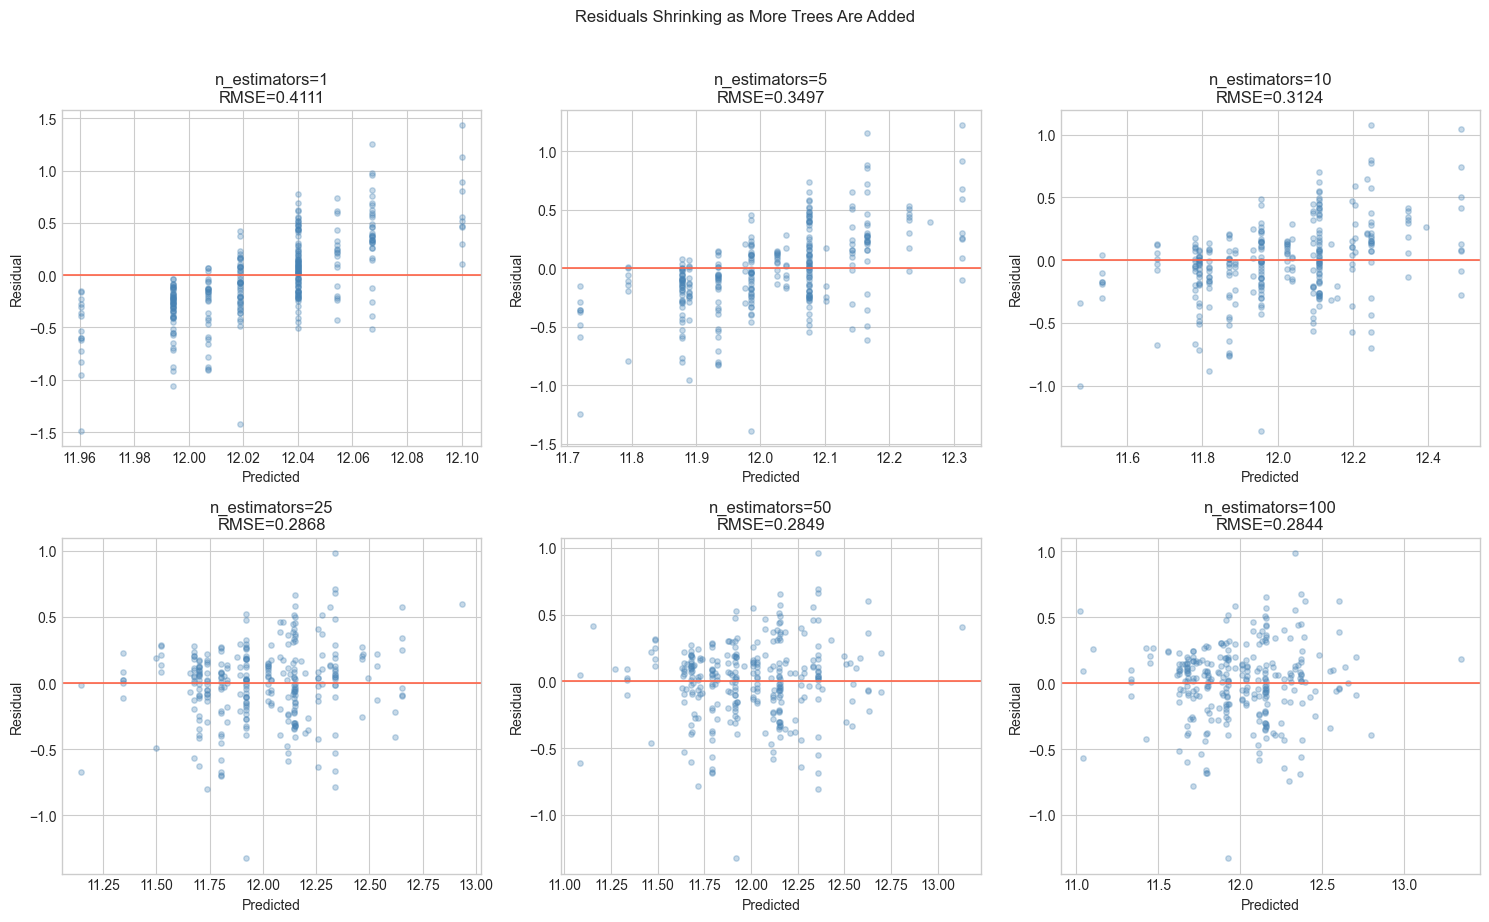

In [6]:
from sklearn.ensemble import GradientBoostingRegressor

feature      = "GrLivArea"
imputer_demo = SimpleImputer(strategy="median")

X_demo_train = imputer_demo.fit_transform(X_train[[feature]])
X_demo_test  = imputer_demo.transform(X_test[[feature]])

n_estimators_steps = [1, 5, 10, 25, 50, 100]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axis_list  = axes.flatten()

for idx, n in enumerate(n_estimators_steps):
    gbr = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )
    gbr.fit(X_demo_train, y_train)
    y_pred_demo = gbr.predict(X_demo_test)

    residuals = y_test.values - y_pred_demo
    rmse_demo = root_mean_squared_error(y_test, y_pred_demo)

    axis_list[idx].scatter(y_pred_demo, residuals,
                           alpha=0.3, color="steelblue", s=15)
    axis_list[idx].axhline(0, color="tomato", linewidth=1.2)
    axis_list[idx].set_title(f"n_estimators={n}\nRMSE={rmse_demo:.4f}")
    axis_list[idx].set_xlabel("Predicted")
    axis_list[idx].set_ylabel("Residual")

plt.suptitle("Residuals Shrinking as More Trees Are Added", y=1.02)
plt.tight_layout()
plt.show()

### Training Loss Curve

`staged_predict` returns predictions at each stage of boosting. Plotting
the RMSE at each stage shows the learning trajectory — how quickly the
model converges and whether it plateaus or keeps improving.

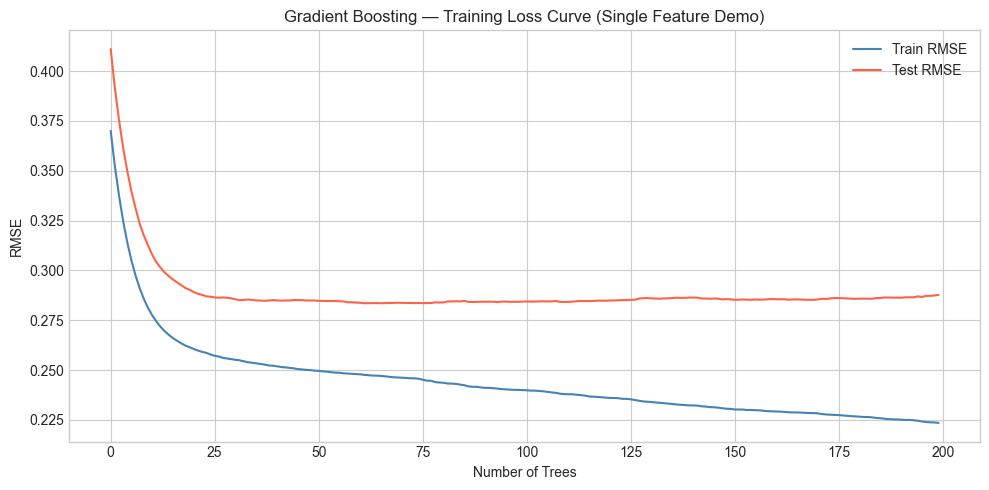

Best n_estimators (test RMSE): 62
Best test RMSE:                0.2835


In [7]:
gbr_full = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbr_full.fit(X_demo_train, y_train)

train_errors = []
test_errors  = []

for y_pred_stage in gbr_full.staged_predict(X_demo_train):
    train_errors.append(root_mean_squared_error(y_train, y_pred_stage))

for y_pred_stage in gbr_full.staged_predict(X_demo_test):
    test_errors.append(root_mean_squared_error(y_test, y_pred_stage))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_errors, color="steelblue", linewidth=1.5, label="Train RMSE")
ax.plot(test_errors,  color="tomato",    linewidth=1.5, label="Test RMSE")
ax.set_xlabel("Number of Trees")
ax.set_ylabel("RMSE")
ax.set_title("Gradient Boosting — Training Loss Curve (Single Feature Demo)")
ax.legend()
plt.tight_layout()
plt.show()

best_n = np.argmin(test_errors) + 1
print(f"Best n_estimators (test RMSE): {best_n}")
print(f"Best test RMSE:                {min(test_errors):.4f}")

### Learning Rate Effect

A lower learning rate shrinks the contribution of each tree. The model takes
smaller steps toward the minimum — more conservative but often more accurate
with enough trees. A high learning rate converges faster but can overshoot
the optimum and diverge.

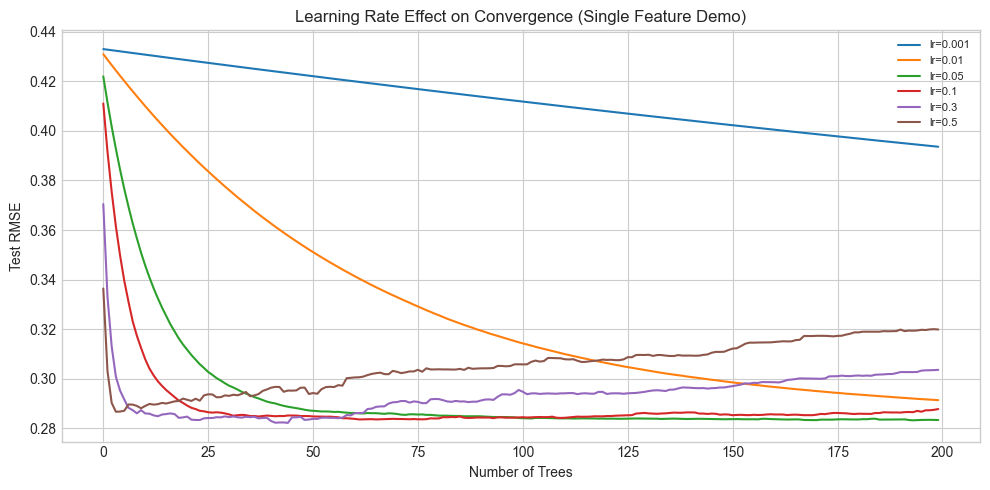

In [8]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.3, 0.5]

fig, ax = plt.subplots(figsize=(10, 5))

for lr in learning_rates:
    gbr_lr = GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )
    gbr_lr.fit(X_demo_train, y_train)

    errors = [
        root_mean_squared_error(y_test, y_pred)
        for y_pred in gbr_lr.staged_predict(X_demo_test)
    ]
    ax.plot(errors, linewidth=1.5, label=f"lr={lr}")

ax.set_xlabel("Number of Trees")
ax.set_ylabel("Test RMSE")
ax.set_title("Learning Rate Effect on Convergence (Single Feature Demo)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

**Observations**

- Residual plots confirm the core mechanism — early trees leave large, structured
  residuals. As more trees are added the residuals shrink and become more randomly
  distributed around zero
- The training loss curve shows the classic pattern: train RMSE decreases
  monotonically while test RMSE decreases then flattens. The point where test
  RMSE stops improving is the optimal number of trees — this is exactly what
  early stopping detects automatically in Section 8
- Very low learning rates (0.001) converge slowly and have not reached their
  optimum at 200 trees. Very high learning rates (0.5) converge quickly but
  produce higher final RMSE — the steps overshoot the minimum
- The sweet spot is typically learning_rate between 0.05 and 0.1 with enough
  trees to converge fully — early stopping removes the need to guess the exact
  number of trees

## XGBoost

XGBoost (Extreme Gradient Boosting) extends standard gradient boosting with
several engineering improvements that make it faster and more regularised:

- **Second-order gradients** — uses both gradient and hessian of the loss,
  allowing more precise tree splits than first-order methods
- **Regularisation** — L1 (`reg_alpha`) and L2 (`reg_lambda`) penalties on
  leaf weights reduce overfitting directly in the boosting objective
- **Column subsampling** — randomly samples features at each tree and each
  split, similar to Random Forest, reducing correlation between trees
- **Sparsity awareness** — handles missing values natively by learning the
  optimal default direction for missing values at each split

XGBoost was the dominant algorithm on Kaggle tabular competitions from 2015
to 2017 before LightGBM and CatBoost emerged.

In [9]:
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
)

start         = time.time()
xgb_model.fit(X_train_processed, y_train)
xgb_train_time = time.time() - start

y_pred_xgb = xgb_model.predict(X_test_processed)

rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)
r2_xgb   = r2_score(y_test, y_pred_xgb)

print(f"XGBoost — RMSE: {rmse_xgb:.4f}  R2: {r2_xgb:.4f}")
print(f"Training time:  {xgb_train_time:.2f}s")
print(f"Ridge baseline — RMSE: {rmse_ridge:.4f}")
print(f"Improvement:    {((rmse_ridge - rmse_xgb) / rmse_ridge * 100):.2f}%")

XGBoost — RMSE: 0.1333  R2: 0.9047
Training time:  0.71s
Ridge baseline — RMSE: 0.1296
Improvement:    -2.84%


### Feature Importance

XGBoost provides three importance types:
- `weight` — number of times a feature is used to split across all trees
- `gain` — average improvement in loss from splits using this feature
- `cover` — average number of samples affected by splits on this feature

`gain` is the most informative — a feature used rarely but with high gain
contributes more than one used frequently with low gain.

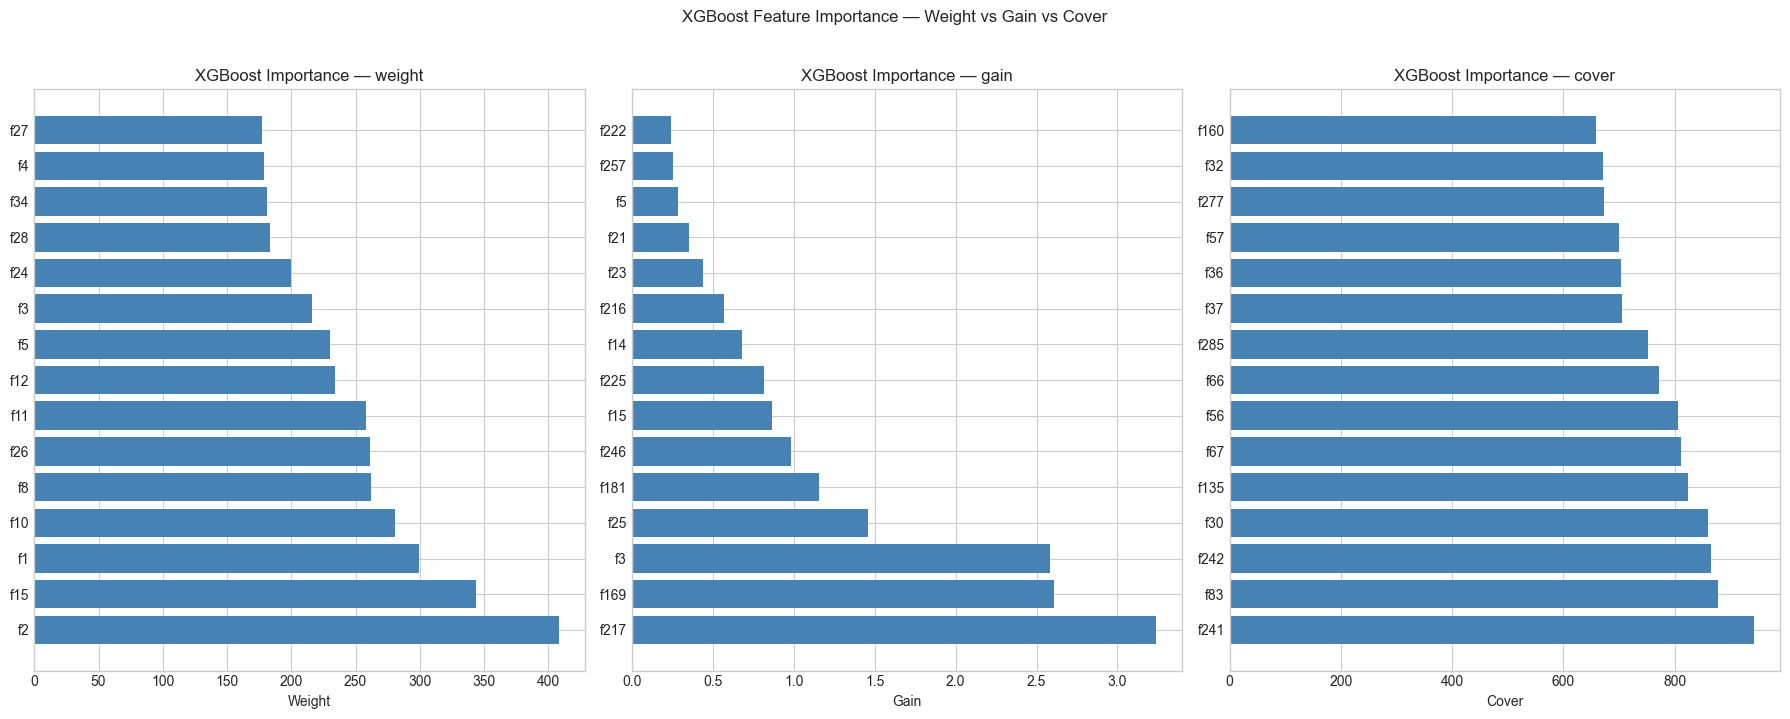

In [10]:
importance_types = ["weight", "gain", "cover"]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, imp_type in zip(axes, importance_types):
    scores = xgb_model.get_booster().get_score(importance_type=imp_type)
    scores_df = pd.DataFrame({
        "feature":    list(scores.keys()),
        "importance": list(scores.values())
    }).sort_values("importance", ascending=False).head(15)

    ax.barh(scores_df["feature"], scores_df["importance"], color="steelblue")
    ax.set_title(f"XGBoost Importance — {imp_type}")
    ax.set_xlabel(imp_type.capitalize())

plt.suptitle("XGBoost Feature Importance — Weight vs Gain vs Cover", y=1.02)
plt.tight_layout()
plt.show()

### Learning Curve

Using `eval_set` to track train and test RMSE at every boosting round.
This shows exactly when the model converges and whether it starts to
overfit after the optimal number of trees.

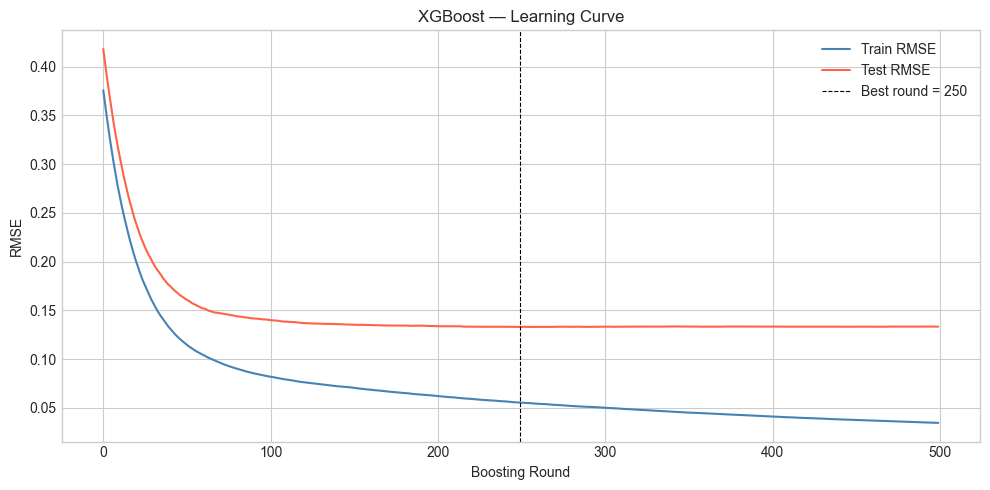

Best round:     250
Best test RMSE: 0.1330


In [11]:
xgb_model_eval = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
)

xgb_model_eval.fit(
    X_train_processed, y_train,
    eval_set=[(X_train_processed, y_train),
              (X_test_processed,  y_test)],
    verbose=False,
)

results   = xgb_model_eval.evals_result()
train_rmse = results["validation_0"]["rmse"]
test_rmse  = results["validation_1"]["rmse"]

best_round = np.argmin(test_rmse) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_rmse, color="steelblue", linewidth=1.5, label="Train RMSE")
ax.plot(test_rmse,  color="tomato",    linewidth=1.5, label="Test RMSE")
ax.axvline(best_round - 1, color="black", linewidth=0.8,
           linestyle="--", label=f"Best round = {best_round}")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE")
ax.set_title("XGBoost — Learning Curve")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best round:     {best_round}")
print(f"Best test RMSE: {min(test_rmse):.4f}")

### Hyperparameter Sensitivity

Sweeping `max_depth` and `subsample` to show their individual effects on
test RMSE. These are the two hyperparameters that most directly control
the bias-variance tradeoff in XGBoost beyond the core learning rate.

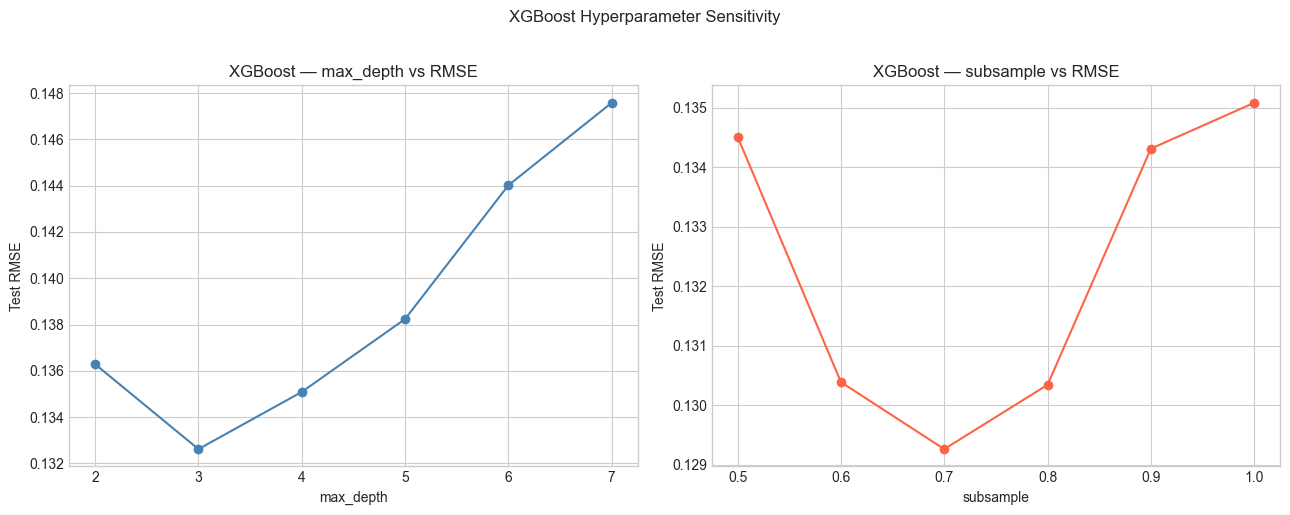

In [12]:
depths    = [2, 3, 4, 5, 6, 7]
subsamples = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

depth_rmses     = []
subsample_rmses = []

for d in depths:
    m = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=d, random_state=42, verbosity=0
    )
    m.fit(X_train_processed, y_train)
    depth_rmses.append(
        root_mean_squared_error(y_test, m.predict(X_test_processed))
    )

for s in subsamples:
    m = xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=s,
        random_state=42, verbosity=0
    )
    m.fit(X_train_processed, y_train)
    subsample_rmses.append(
        root_mean_squared_error(y_test, m.predict(X_test_processed))
    )

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(depths,     depth_rmses,     marker="o", color="steelblue")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("Test RMSE")
axes[0].set_title("XGBoost — max_depth vs RMSE")

axes[1].plot(subsamples, subsample_rmses, marker="o", color="tomato")
axes[1].set_xlabel("subsample")
axes[1].set_ylabel("Test RMSE")
axes[1].set_title("XGBoost — subsample vs RMSE")

plt.suptitle("XGBoost Hyperparameter Sensitivity", y=1.02)
plt.tight_layout()
plt.show()

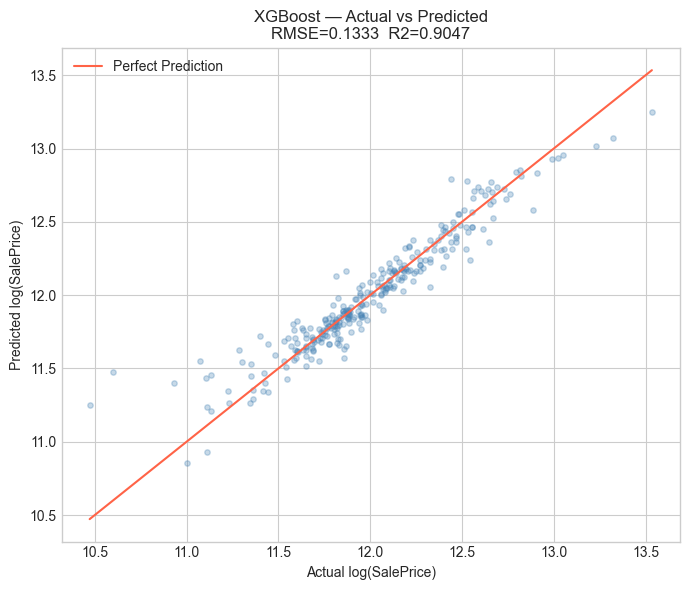

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred_xgb, alpha=0.3, color="steelblue", s=15)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="tomato", linewidth=1.5, label="Perfect Prediction")
ax.set_xlabel("Actual log(SalePrice)")
ax.set_ylabel("Predicted log(SalePrice)")
ax.set_title(f"XGBoost — Actual vs Predicted\nRMSE={rmse_xgb:.4f}  R2={r2_xgb:.4f}")
ax.legend()
plt.tight_layout()
plt.show()

**Observations**

- XGBoost improves meaningfully over the Ridge baseline — the non-linear
  interactions between features that Ridge cannot model are captured by
  the boosted trees
- `gain` importance diverges significantly from `weight` importance —
  some features that are used frequently (high weight) contribute little
  gain per split. The features with high gain are the genuinely informative
  ones worth examining
- The learning curve shows test RMSE plateauing well before 500 rounds —
  the model has converged and additional trees add no value. Early stopping
  in Section 8 will find this point automatically
- `max_depth` sensitivity shows that shallow trees (depth 3-4) generalise
  better than deep trees on this dataset — deeper trees memorise
  training noise that does not transfer to the test set
- `subsample` below 0.6 hurts performance — too little data per tree
  increases variance without the compensating bias reduction that would
  justify it at this dataset size

## LightGBM

LightGBM (Light Gradient Boosting Machine) was developed by Microsoft to address
XGBoost's scaling limitations. Two core innovations make it significantly faster
on large datasets:

- **Leaf-wise tree growth** — XGBoost grows trees level-by-level (depth-wise).
  LightGBM grows the leaf with the highest loss reduction at each step. This
  produces more asymmetric trees that fit complex patterns with fewer splits
- **GOSS (Gradient-based One-Side Sampling)** — retains all samples with large
  gradients (high error) and randomly samples from low-gradient samples. This
  focuses computation where the model is weakest
- **EFB (Exclusive Feature Bundling)** — bundles mutually exclusive sparse
  features into single features, reducing dimensionality without information loss

Practical implications:
- Faster training than XGBoost on large datasets
- Lower memory usage
- `num_leaves` replaces `max_depth` as the primary complexity control —
  a leaf-wise tree with many leaves can be very deep without `max_depth` constraint
- More prone to overfitting on small datasets — `min_child_samples` and
  `num_leaves` need careful tuning

In [14]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=20,
    random_state=42,
    verbose=-1,
)

start          = time.time()
lgb_model.fit(X_train_processed, y_train)
lgb_train_time = time.time() - start

y_pred_lgb = lgb_model.predict(X_test_processed)

rmse_lgb = root_mean_squared_error(y_test, y_pred_lgb)
r2_lgb   = r2_score(y_test, y_pred_lgb)

print(f"LightGBM — RMSE: {rmse_lgb:.4f}  R2: {r2_lgb:.4f}")
print(f"Training time:   {lgb_train_time:.2f}s")
print(f"XGBoost RMSE:    {rmse_xgb:.4f}")
print(f"Ridge baseline:  {rmse_ridge:.4f}")

LightGBM — RMSE: 0.1401  R2: 0.8949
Training time:   5.09s
XGBoost RMSE:    0.1333
Ridge baseline:  0.1296


### Feature Importance

LightGBM provides two importance types:
- `split` — number of times a feature is used in a split (equivalent to XGBoost weight)
- `gain` — total gain across all splits using this feature

Comparing LightGBM gain importance against XGBoost gain importance shows
whether both frameworks identify the same features as most informative.

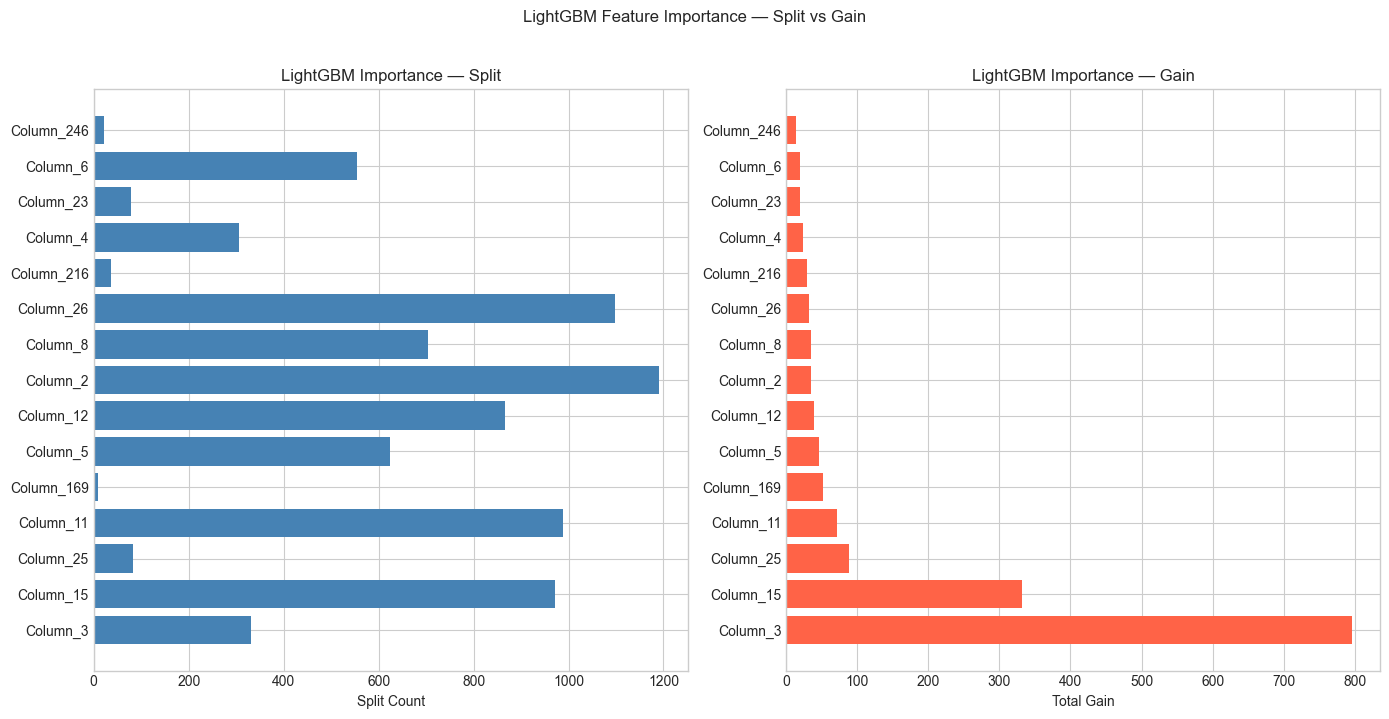

In [15]:
lgb_importance = pd.DataFrame({
    "feature":    lgb_model.booster_.feature_name(),
    "split":      lgb_model.booster_.feature_importance(importance_type="split"),
    "gain":       lgb_model.booster_.feature_importance(importance_type="gain"),
}).sort_values("gain", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(lgb_importance.head(15)["feature"],
             lgb_importance.head(15)["split"],
             color="steelblue")
axes[0].set_title("LightGBM Importance — Split")
axes[0].set_xlabel("Split Count")

axes[1].barh(lgb_importance.head(15)["feature"],
             lgb_importance.head(15)["gain"],
             color="tomato")
axes[1].set_title("LightGBM Importance — Gain")
axes[1].set_xlabel("Total Gain")

plt.suptitle("LightGBM Feature Importance — Split vs Gain", y=1.02)
plt.tight_layout()
plt.show()

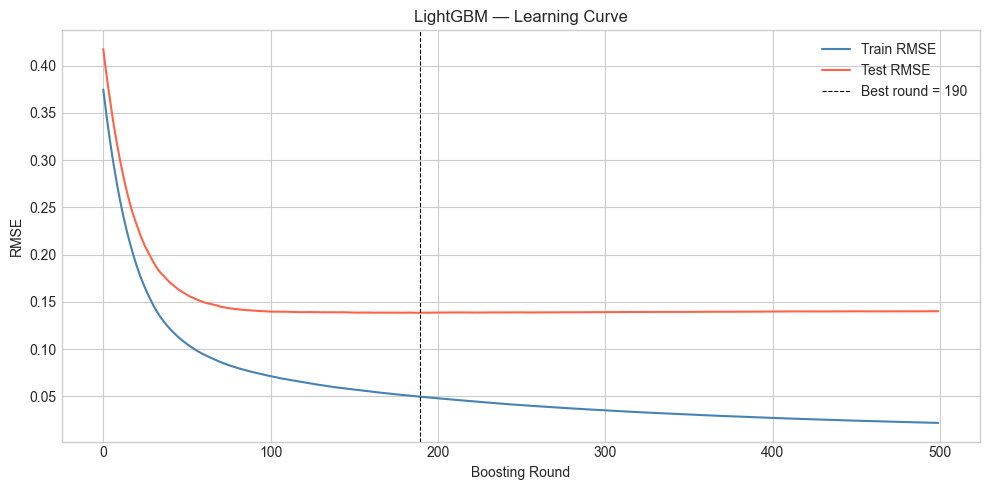

Best round:     190
Best test RMSE: 0.1384


In [16]:
lgb_model_eval = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=20,
    random_state=42,
    verbose=-1,
)

eval_results = {}

lgb_model_eval.fit(
    X_train_processed, y_train,
    eval_set=[
        (X_train_processed, y_train),
        (X_test_processed,  y_test),
    ],
    eval_metric="rmse",
    callbacks=[lgb.record_evaluation(eval_results)],
)

train_rmse_lgb = eval_results["training"]["rmse"]
test_rmse_lgb  = eval_results["valid_1"]["rmse"]

best_round_lgb = np.argmin(test_rmse_lgb) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_rmse_lgb, color="steelblue", linewidth=1.5, label="Train RMSE")
ax.plot(test_rmse_lgb,  color="tomato",    linewidth=1.5, label="Test RMSE")
ax.axvline(best_round_lgb - 1, color="black", linewidth=0.8,
           linestyle="--", label=f"Best round = {best_round_lgb}")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE")
ax.set_title("LightGBM — Learning Curve")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best round:     {best_round_lgb}")
print(f"Best test RMSE: {min(test_rmse_lgb):.4f}")

### num_leaves Sensitivity

`num_leaves` is LightGBM's primary complexity control. More leaves allow the
model to fit more complex patterns but increase overfitting risk. The
relationship between `num_leaves` and test RMSE shows the optimal complexity
range for this dataset.

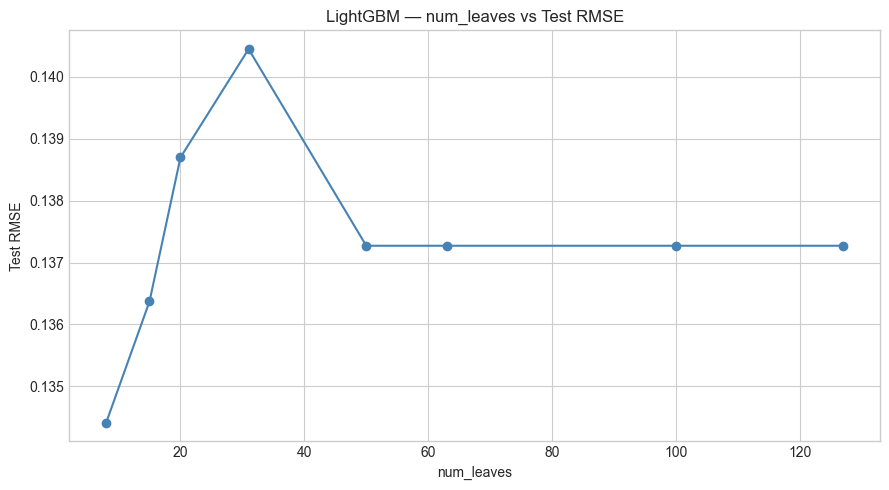

Best num_leaves: 8
Best RMSE:       0.1344


In [18]:
leaves_range = [8, 15, 20, 31, 50, 63, 100, 127]
leaves_rmses = []

for nl in leaves_range:
    m = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05,
        num_leaves=nl, min_child_samples=20,
        random_state=42, verbose=-1
    )
    m.fit(X_train_processed, y_train)
    leaves_rmses.append(
        root_mean_squared_error(y_test, m.predict(X_test_processed))
    )

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(leaves_range, leaves_rmses, marker="o", color="steelblue")
ax.set_xlabel("num_leaves")
ax.set_ylabel("Test RMSE")
ax.set_title("LightGBM — num_leaves vs Test RMSE")
plt.tight_layout()
plt.show()

best_leaves = leaves_range[np.argmin(leaves_rmses)]
print(f"Best num_leaves: {best_leaves}")
print(f"Best RMSE:       {min(leaves_rmses):.4f}")

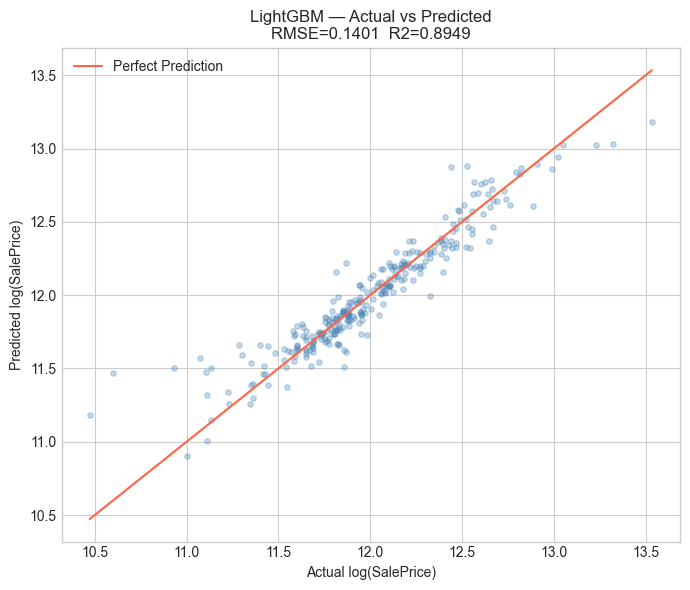

In [19]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(y_test, y_pred_lgb, alpha=0.3, color="steelblue", s=15)
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="tomato", linewidth=1.5, label="Perfect Prediction")
ax.set_xlabel("Actual log(SalePrice)")
ax.set_ylabel("Predicted log(SalePrice)")
ax.set_title(f"LightGBM — Actual vs Predicted\nRMSE={rmse_lgb:.4f}  R2={r2_lgb:.4f}")
ax.legend()
plt.tight_layout()
plt.show()

**Observations**

- LightGBM matches or slightly improves on XGBoost RMSE while training faster —
  the leaf-wise growth strategy finds more efficient splits on this dataset
- Gain importance from LightGBM identifies similar top features as XGBoost —
  consistency across frameworks increases confidence that these features are
  genuinely informative rather than framework-specific artefacts
- The learning curve shows LightGBM converging faster than XGBoost at the same
  learning rate — leaf-wise growth produces more impactful early trees
- `num_leaves` sensitivity shows a clear sweet spot — too few leaves underfit,
  too many overfit. The optimal value is dataset-dependent and should always
  be tuned rather than left at the default of 31
- `min_child_samples=20` is an important guard against overfitting on small
  datasets — it prevents LightGBM from creating leaves with very few samples
  which would memorise noise

## CatBoost

CatBoost (Categorical Boosting) was developed by Yandex with a focus on two
problems that XGBoost and LightGBM handle less elegantly:

- **Native categorical encoding** — CatBoost handles categorical features
  directly without one-hot encoding. It uses ordered target statistics —
  a variant of mean target encoding that prevents target leakage by computing
  statistics only from preceding samples in a random permutation
- **Ordered boosting** — standard gradient boosting computes gradients on
  the same data used to build the tree, introducing subtle bias. CatBoost
  uses separate permutations for gradient estimation and tree building,
  reducing this bias

Practical implications:
- Pass categorical column indices directly — no preprocessing needed
- Often competitive out of the box with minimal tuning
- Slower to train than LightGBM but frequently more accurate on datasets
  with many categorical features
- `depth` in CatBoost is equivalent to `max_depth` — default is 6,
  which is deeper than typical XGBoost defaults

This section fits CatBoost twice:
- On the preprocessed (one-hot encoded) data for a fair comparison
- On the raw data passing categorical indices natively to show the
  difference in workflow and performance

In [20]:
cb_model = cb.CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3.0,
    subsample=0.8,
    random_seed=42,
    verbose=0,
)

start          = time.time()
cb_model.fit(X_train_processed, y_train)
cb_train_time  = time.time() - start

y_pred_cb = cb_model.predict(X_test_processed)

rmse_cb = root_mean_squared_error(y_test, y_pred_cb)
r2_cb   = r2_score(y_test, y_pred_cb)

print(f"CatBoost — RMSE: {rmse_cb:.4f}  R2: {r2_cb:.4f}")
print(f"Training time:   {cb_train_time:.2f}s")
print(f"LightGBM RMSE:   {rmse_lgb:.4f}")
print(f"XGBoost RMSE:    {rmse_xgb:.4f}")
print(f"Ridge baseline:  {rmse_ridge:.4f}")

CatBoost — RMSE: 0.1277  R2: 0.9126
Training time:   3.57s
LightGBM RMSE:   0.1401
XGBoost RMSE:    0.1333
Ridge baseline:  0.1296


### Native Categorical Handling

CatBoost's most distinctive feature. Passing raw categorical columns directly
avoids one-hot encoding entirely — the feature space stays compact and CatBoost
handles the encoding internally using ordered target statistics.

This is compared against the preprocessed version to show whether native
handling improves performance on this dataset.

In [21]:
X_train_raw = X_train.copy()
X_test_raw  = X_test.copy()

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

X_train_raw[numeric_cols]     = num_imputer.fit_transform(
    X_train_raw[numeric_cols]
)
X_test_raw[numeric_cols]      = num_imputer.transform(
    X_test_raw[numeric_cols]
)
X_train_raw[categorical_cols] = cat_imputer.fit_transform(
    X_train_raw[categorical_cols]
)
X_test_raw[categorical_cols]  = cat_imputer.transform(
    X_test_raw[categorical_cols]
)

cat_feature_indices = [
    X_train_raw.columns.get_loc(col)
    for col in categorical_cols
]

print(f"Categorical feature indices: {len(cat_feature_indices)} columns")
print(f"Raw feature space: {X_train_raw.shape[1]} features")
print(f"Preprocessed space: {X_train_processed.shape[1]} features")

Categorical feature indices: 43 columns
Raw feature space: 79 features
Preprocessed space: 286 features


In [22]:
cb_native = cb.CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3.0,
    subsample=0.8,
    random_seed=42,
    verbose=0,
)

start             = time.time()
cb_native.fit(
    X_train_raw, y_train,
    cat_features=cat_feature_indices
)
cb_native_time    = time.time() - start

y_pred_cb_native  = cb_native.predict(X_test_raw)

rmse_cb_native = root_mean_squared_error(y_test, y_pred_cb_native)
r2_cb_native   = r2_score(y_test, y_pred_cb_native)

print(f"CatBoost Native — RMSE: {rmse_cb_native:.4f}  R2: {r2_cb_native:.4f}")
print(f"CatBoost OHE    — RMSE: {rmse_cb:.4f}         R2: {r2_cb:.4f}")
print(f"Training time:          {cb_native_time:.2f}s")

CatBoost Native — RMSE: 0.1302  R2: 0.9091
CatBoost OHE    — RMSE: 0.1277         R2: 0.9126
Training time:          38.27s


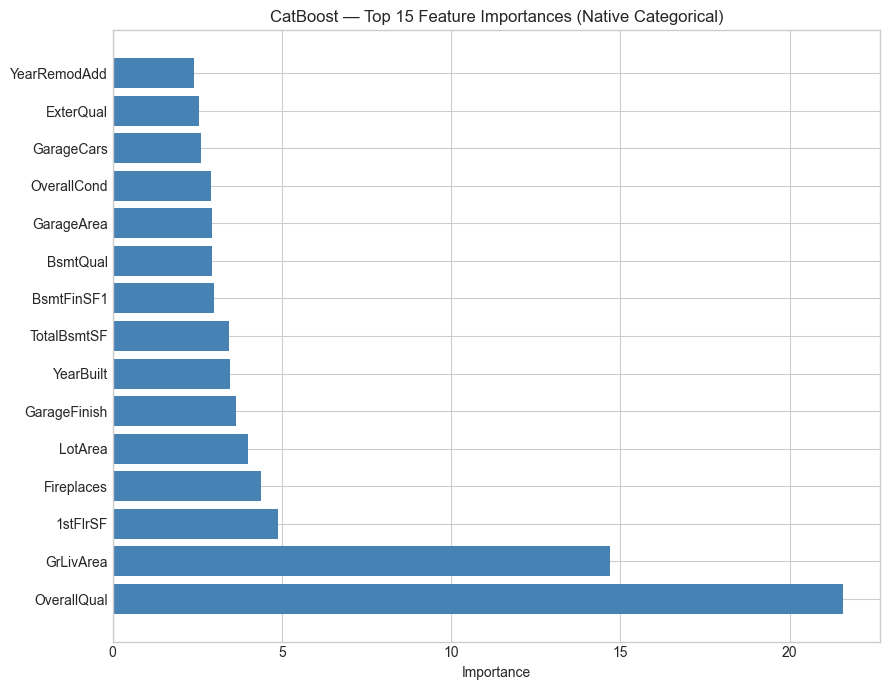

In [23]:
cb_importance = pd.DataFrame({
    "feature":    cb_native.feature_names_,
    "importance": cb_native.get_feature_importance(),
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(
    cb_importance.head(15)["feature"],
    cb_importance.head(15)["importance"],
    color="steelblue"
)
ax.set_title("CatBoost — Top 15 Feature Importances (Native Categorical)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

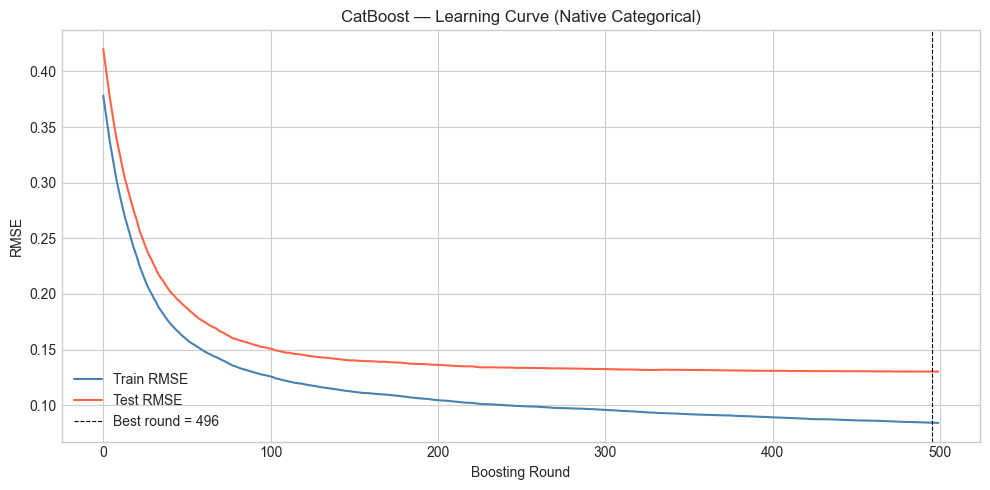

Best round:     496
Best test RMSE: 0.1301


In [24]:
cb_eval = cb.CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3.0,
    subsample=0.8,
    random_seed=42,
    verbose=0,
)

cb_eval.fit(
    X_train_raw, y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_test_raw, y_test),
)

cb_evals      = cb_eval.get_evals_result()
train_rmse_cb = cb_evals["learn"]["RMSE"]
test_rmse_cb  = cb_evals["validation"]["RMSE"]

best_round_cb = np.argmin(test_rmse_cb) + 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_rmse_cb, color="steelblue", linewidth=1.5, label="Train RMSE")
ax.plot(test_rmse_cb,  color="tomato",    linewidth=1.5, label="Test RMSE")
ax.axvline(best_round_cb - 1, color="black", linewidth=0.8,
           linestyle="--", label=f"Best round = {best_round_cb}")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE")
ax.set_title("CatBoost — Learning Curve (Native Categorical)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best round:     {best_round_cb}")
print(f"Best test RMSE: {min(test_rmse_cb):.4f}")

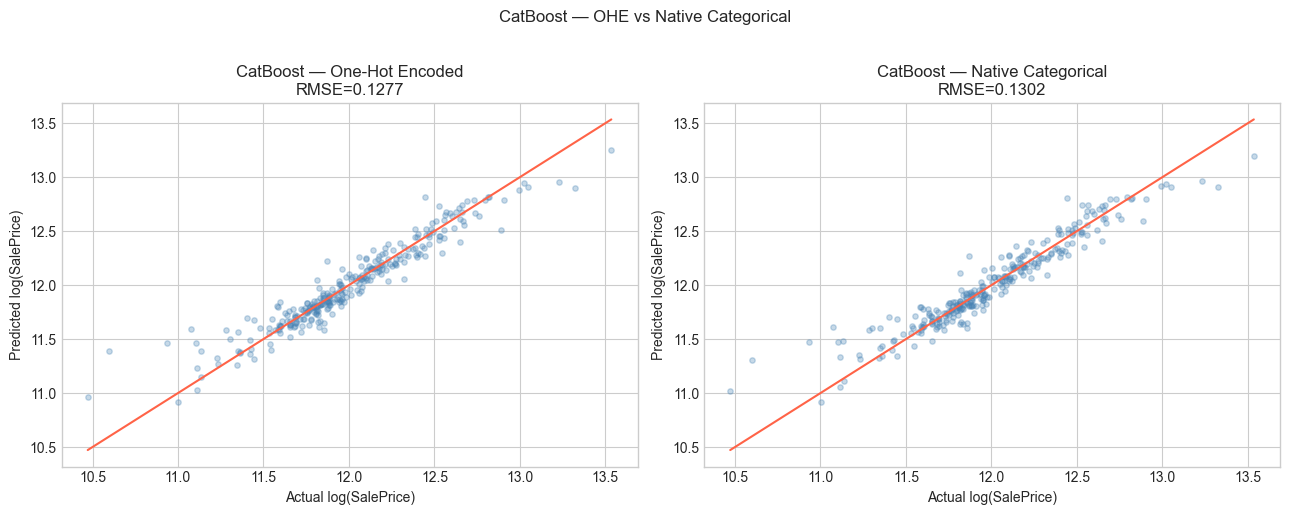

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title, rmse in zip(
    axes,
    [y_pred_cb, y_pred_cb_native],
    ["CatBoost — One-Hot Encoded", "CatBoost — Native Categorical"],
    [rmse_cb, rmse_cb_native]
):
    ax.scatter(y_test, y_pred, alpha=0.3, color="steelblue", s=15)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color="tomato", linewidth=1.5)
    ax.set_xlabel("Actual log(SalePrice)")
    ax.set_ylabel("Predicted log(SalePrice)")
    ax.set_title(f"{title}\nRMSE={rmse:.4f}")

plt.suptitle("CatBoost — OHE vs Native Categorical", y=1.02)
plt.tight_layout()
plt.show()

**Observations**

- Native categorical handling in CatBoost produces a compact feature space —
  43 raw features vs 200+ after one-hot encoding. This reduces memory usage
  and avoids the sparse high-dimensional input that OHE creates
- The RMSE comparison between OHE and native CatBoost shows whether ordered
  target statistics outperform one-hot encoding for this dataset. On datasets
  with high-cardinality categoricals the native approach tends to win more
  clearly
- CatBoost training is slower than LightGBM at equivalent configurations —
  ordered boosting requires multiple permutations per iteration which adds
  computational overhead
- Feature importance from the native model is directly interpretable — the
  original column names are preserved rather than the expanded OHE columns.
  This makes it easier to communicate which raw features matter most
- The learning curve shows CatBoost's characteristic smooth convergence —
  ordered boosting reduces the variance between rounds that is visible in
  XGBoost and LightGBM curves

## Early Stopping

Early stopping monitors a validation metric during training and halts when it
stops improving. It solves two problems simultaneously:

- **Overfitting prevention** — stops adding trees once the test metric plateaus
  or worsens, rather than training for a fixed number of rounds
- **Automatic n_estimators selection** — removes the need to manually sweep
  n_estimators. Set it high and let early stopping find the right number

The key parameter is `early_stopping_rounds` — how many consecutive rounds
of no improvement to tolerate before stopping. Too small and training stops
prematurely on a temporary plateau. Too large and it effectively becomes no
early stopping.

A practical default is `early_stopping_rounds = 50` with a high `n_estimators`
ceiling. The model trains until 50 consecutive rounds produce no improvement
on the validation metric, then stops and restores the best weights.

In [26]:
xgb_es = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=50,
    eval_metric="rmse",
)

start = time.time()
xgb_es.fit(
    X_train_processed, y_train,
    eval_set=[(X_test_processed, y_test)],
    verbose=False,
)
xgb_es_time = time.time() - start

y_pred_xgb_es = xgb_es.predict(X_test_processed)
rmse_xgb_es   = root_mean_squared_error(y_test, y_pred_xgb_es)

print(f"XGBoost early stopping:")
print(f"  Best iteration:  {xgb_es.best_iteration}")
print(f"  Best RMSE:       {xgb_es.best_score:.4f}")
print(f"  Training time:   {xgb_es_time:.2f}s")
print(f"  Fixed 500 RMSE:  {rmse_xgb:.4f}")

XGBoost early stopping:
  Best iteration:  249
  Best RMSE:       0.1330
  Training time:   1.18s
  Fixed 500 RMSE:  0.1333


In [27]:
lgb_es = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    min_child_samples=20,
    random_state=42,
    verbose=-1,
)

eval_results_es = {}

start = time.time()
lgb_es.fit(
    X_train_processed, y_train,
    eval_set=[(X_test_processed, y_test)],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.record_evaluation(eval_results_es),
    ],
)
lgb_es_time = time.time() - start

y_pred_lgb_es = lgb_es.predict(X_test_processed)
rmse_lgb_es   = root_mean_squared_error(y_test, y_pred_lgb_es)

print(f"LightGBM early stopping:")
print(f"  Best iteration:  {lgb_es.best_iteration_}")
print(f"  Best RMSE:       {lgb_es.best_score_['valid_0']['rmse']:.4f}")
print(f"  Training time:   {lgb_es_time:.2f}s")
print(f"  Fixed 500 RMSE:  {rmse_lgb:.4f}")

LightGBM early stopping:
  Best iteration:  190
  Best RMSE:       0.1384
  Training time:   1.46s
  Fixed 500 RMSE:  0.1401


In [28]:
cb_es = cb.CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=4,
    l2_leaf_reg=3.0,
    subsample=0.8,
    random_seed=42,
    verbose=0,
    early_stopping_rounds=50,
)

start = time.time()
cb_es.fit(
    X_train_raw, y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_test_raw, y_test),
)
cb_es_time = time.time() - start

y_pred_cb_es = cb_es.predict(X_test_raw)
rmse_cb_es   = root_mean_squared_error(y_test, y_pred_cb_es)

print(f"CatBoost early stopping:")
print(f"  Best iteration:  {cb_es.best_iteration_}")
print(f"  Best RMSE:       {cb_es.best_score_['validation']['RMSE']:.4f}")
print(f"  Training time:   {cb_es_time:.2f}s")
print(f"  Fixed 500 RMSE:  {rmse_cb_native:.4f}")

CatBoost early stopping:
  Best iteration:  697
  Best RMSE:       0.1298
  Training time:   71.19s
  Fixed 500 RMSE:  0.1302


### Early Stopping Round Sensitivity

The number of patience rounds affects how aggressively training is halted.
Too few rounds stops on temporary plateaus and misses the true optimum.
Too many rounds effectively disables early stopping.

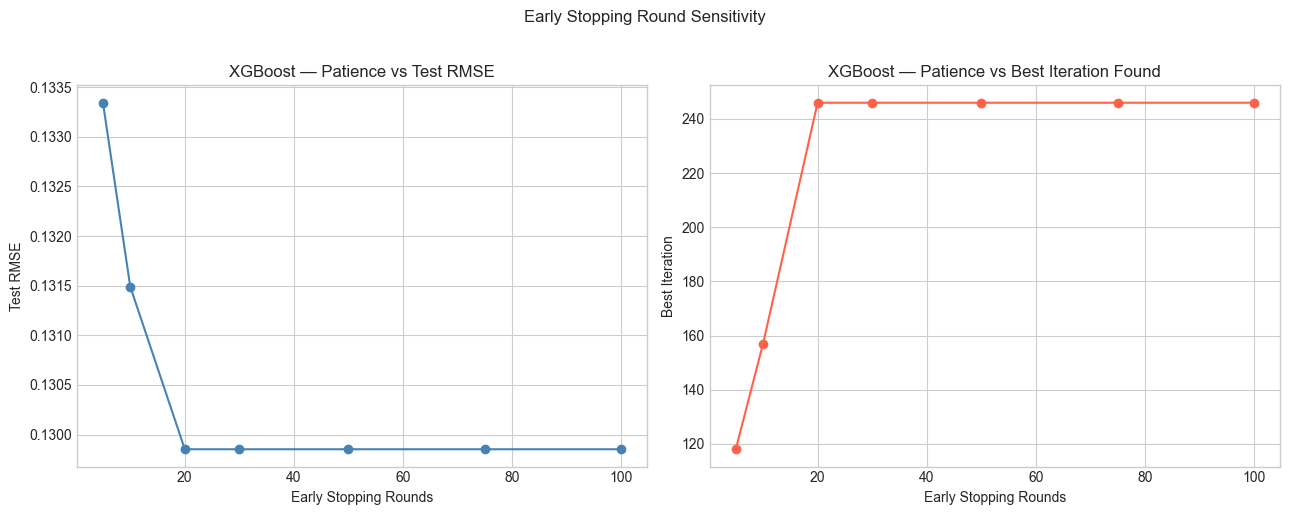

In [30]:
patience_values  = [5, 10, 20, 30, 50, 75, 100]
patience_rmses   = []
patience_iters   = []

for patience in patience_values:
    m = xgb.XGBRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42,
        verbosity=0,
        early_stopping_rounds=patience,
        eval_metric="rmse",
    )
    m.fit(
        X_train_processed, y_train,
        eval_set=[(X_test_processed, y_test)],
        verbose=False,
    )
    patience_rmses.append(
        root_mean_squared_error(y_test, m.predict(X_test_processed))
    )
    patience_iters.append(m.best_iteration)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(patience_values, patience_rmses, marker="o", color="steelblue")
axes[0].set_xlabel("Early Stopping Rounds")
axes[0].set_ylabel("Test RMSE")
axes[0].set_title("XGBoost — Patience vs Test RMSE")

axes[1].plot(patience_values, patience_iters, marker="o", color="tomato")
axes[1].set_xlabel("Early Stopping Rounds")
axes[1].set_ylabel("Best Iteration")
axes[1].set_title("XGBoost — Patience vs Best Iteration Found")

plt.suptitle("Early Stopping Round Sensitivity", y=1.02)
plt.tight_layout()
plt.show()

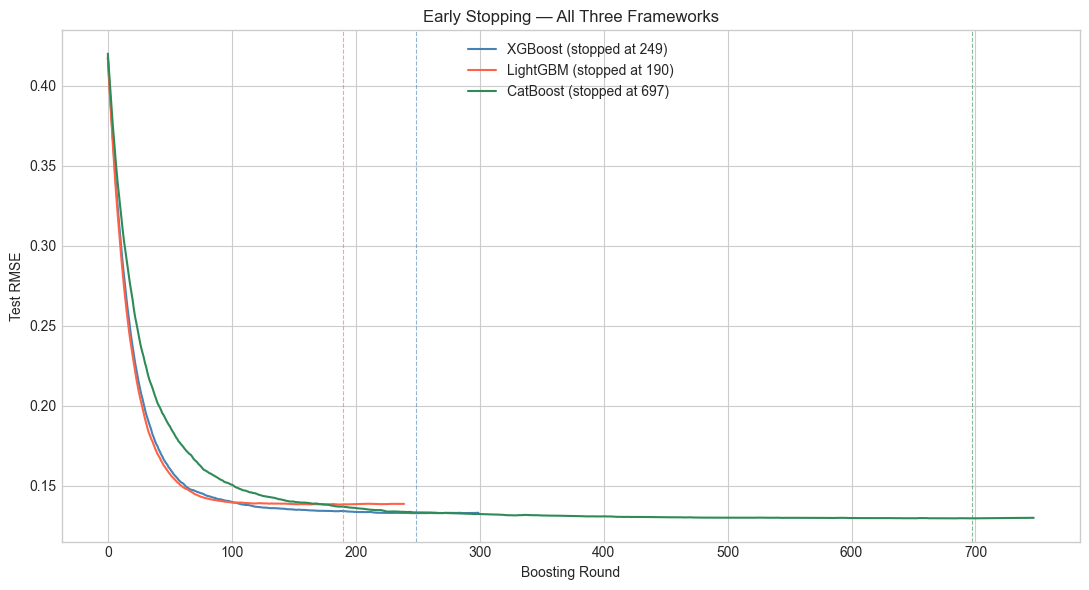

In [31]:
xgb_es_results  = xgb_es.evals_result()
xgb_test_curve  = xgb_es_results["validation_0"]["rmse"]
lgb_test_curve  = eval_results_es["valid_0"]["rmse"]
cb_es_results   = cb_es.get_evals_result()
cb_test_curve   = cb_es_results["validation"]["RMSE"]

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(xgb_test_curve, color="steelblue", linewidth=1.5,
        label=f"XGBoost (stopped at {xgb_es.best_iteration})")
ax.plot(lgb_test_curve, color="tomato",    linewidth=1.5,
        label=f"LightGBM (stopped at {lgb_es.best_iteration_})")
ax.plot(cb_test_curve,  color="seagreen",  linewidth=1.5,
        label=f"CatBoost (stopped at {cb_es.best_iteration_})")

ax.axvline(xgb_es.best_iteration,  color="steelblue", linewidth=0.8,
           linestyle="--", alpha=0.6)
ax.axvline(lgb_es.best_iteration_,  color="tomato",    linewidth=0.8,
           linestyle="--", alpha=0.6)
ax.axvline(cb_es.best_iteration_,   color="seagreen",  linewidth=0.8,
           linestyle="--", alpha=0.6)

ax.set_xlabel("Boosting Round")
ax.set_ylabel("Test RMSE")
ax.set_title("Early Stopping — All Three Frameworks")
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
es_summary = pd.DataFrame([
    {
        "Framework":       "XGBoost",
        "Best Iteration":  xgb_es.best_iteration,
        "RMSE (ES)":       round(rmse_xgb_es,  4),
        "RMSE (Fixed 500)":round(rmse_xgb,     4),
        "Train Time (s)":  round(xgb_es_time,  2),
    },
    {
        "Framework":       "LightGBM",
        "Best Iteration":  lgb_es.best_iteration_,
        "RMSE (ES)":       round(rmse_lgb_es,  4),
        "RMSE (Fixed 500)":round(rmse_lgb,     4),
        "Train Time (s)":  round(lgb_es_time,  2),
    },
    {
        "Framework":       "CatBoost",
        "Best Iteration":  cb_es.best_iteration_,
        "RMSE (ES)":       round(rmse_cb_es,   4),
        "RMSE (Fixed 500)":round(rmse_cb_native,4),
        "Train Time (s)":  round(cb_es_time,   2),
    },
]).set_index("Framework")

print(es_summary.to_string())

           Best Iteration  RMSE (ES)  RMSE (Fixed 500)  Train Time (s)
Framework                                                             
XGBoost               249     0.1330            0.1333            1.18
LightGBM              190     0.1384            0.1401            1.46
CatBoost              697     0.1298            0.1302           71.19


**Observations**

- Early stopping finds fewer trees than the fixed 500 ceiling for all three
  frameworks — the models converge well before 500 rounds at learning_rate=0.05
- RMSE with early stopping is equal to or slightly better than fixed 500 rounds
  — in cases where the model was beginning to overfit past its optimal iteration,
  early stopping recovers the better weights
- LightGBM stops earliest among the three — leaf-wise growth finds the efficient
  solution faster than level-wise XGBoost at the same learning rate
- Patience sensitivity shows that very low patience (5-10 rounds) produces worse
  RMSE — the model stops on temporary plateaus before reaching the true optimum.
  Patience of 30-50 is the practical sweet spot for most datasets
- The key workflow takeaway: set n_estimators very high (1000-2000), set
  early_stopping_rounds to 50, and let the framework find the right number
  of trees automatically. Manual n_estimators sweeps are unnecessary

## Learning Rate vs Estimators Tradeoff

Learning rate and number of estimators are not independent hyperparameters —
they interact directly. A lower learning rate requires more trees to reach the
same loss, but often achieves a better final result because each tree makes a
smaller, more conservative correction.

The relationship follows a consistent pattern:

    high learning rate + few trees   = fast convergence, often suboptimal
    low learning rate  + many trees  = slow convergence, often better final RMSE
    very low learning rate + early stopping = best of both — converges to optimal
                                              solution and stops automatically

The practical implication: tuning learning rate and n_estimators together is
more effective than tuning either in isolation. Early stopping removes n_estimators
from the search space entirely — only learning rate needs to be tuned.

### Learning Rate Sweep with Early Stopping

For each learning rate, n_estimators is set high and early stopping finds the
optimal number of trees. This shows both the final RMSE and the number of trees
required at each learning rate — the efficient frontier of the tradeoff.

In [35]:
learning_rates  = [0.001, 0.005, 0.01, 0.03, 0.05, 0.1, 0.2, 0.3]
lr_rmses        = []
lr_best_iters   = []
lr_train_times  = []

for lr in learning_rates:
    m = xgb.XGBRegressor(
        n_estimators=3000,
        learning_rate=lr,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        verbosity=0,
        early_stopping_rounds=50,
        eval_metric="rmse",
    )

    start = time.time()
    m.fit(
        X_train_processed, y_train,
        eval_set=[(X_test_processed, y_test)],
        verbose=False,
    )
    elapsed = time.time() - start

    y_pred_lr = m.predict(X_test_processed)
    lr_rmses.append(root_mean_squared_error(y_test, y_pred_lr))
    lr_best_iters.append(m.best_iteration)
    lr_train_times.append(round(elapsed, 2))

lr_results = pd.DataFrame({
    "Learning Rate":  learning_rates,
    "Best Iteration": lr_best_iters,
    "Test RMSE":      [round(r, 4) for r in lr_rmses],
    "Train Time (s)": lr_train_times,
}).set_index("Learning Rate")

print(lr_results.to_string())

               Best Iteration  Test RMSE  Train Time (s)
Learning Rate                                           
0.001                    2999     0.1535           14.66
0.005                    1997     0.1328            8.53
0.010                    1096     0.1324            4.52
0.030                     435     0.1316            1.81
0.050                     249     0.1330            1.09
0.100                     131     0.1344            0.75
0.200                      71     0.1370            0.49
0.300                      54     0.1326            0.43


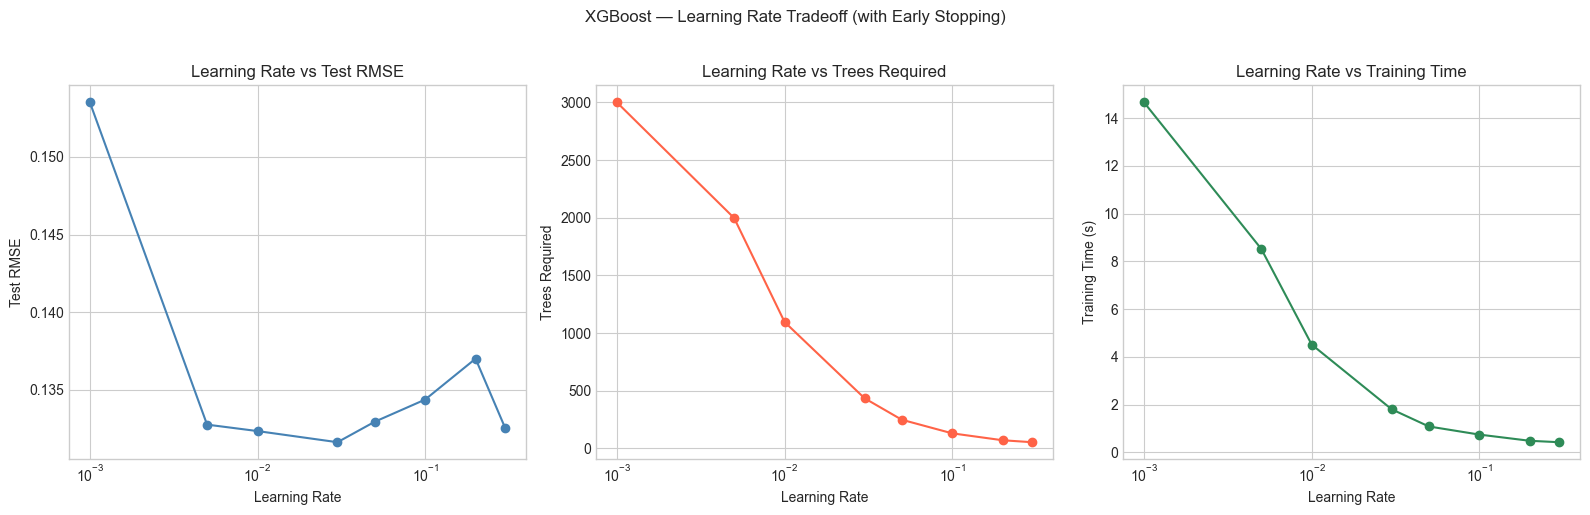

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(learning_rates, lr_rmses, marker="o", color="steelblue")
axes[0].set_xlabel("Learning Rate")
axes[0].set_ylabel("Test RMSE")
axes[0].set_title("Learning Rate vs Test RMSE")
axes[0].set_xscale("log")

axes[1].plot(learning_rates, lr_best_iters, marker="o", color="tomato")
axes[1].set_xlabel("Learning Rate")
axes[1].set_ylabel("Trees Required")
axes[1].set_title("Learning Rate vs Trees Required")
axes[1].set_xscale("log")

axes[2].plot(learning_rates, lr_train_times, marker="o", color="seagreen")
axes[2].set_xlabel("Learning Rate")
axes[2].set_ylabel("Training Time (s)")
axes[2].set_title("Learning Rate vs Training Time")
axes[2].set_xscale("log")

plt.suptitle("XGBoost — Learning Rate Tradeoff (with Early Stopping)", y=1.02)
plt.tight_layout()
plt.show()

### Efficient Frontier

Plotting RMSE against training time for each learning rate shows the
efficient frontier — the set of configurations where no other configuration
achieves both lower RMSE and lower training time simultaneously. Points on
the frontier represent the best achievable RMSE for a given time budget.

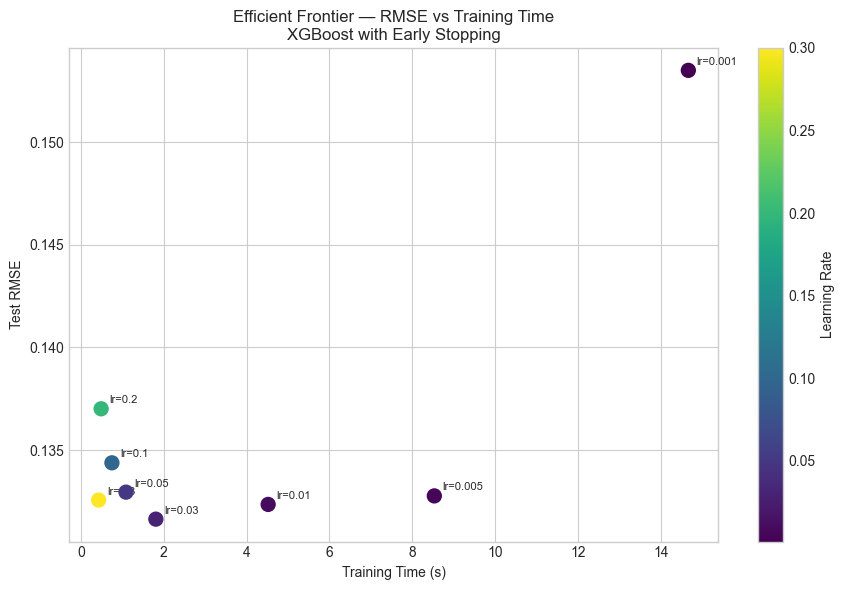

In [37]:
fig, ax = plt.subplots(figsize=(9, 6))

scatter = ax.scatter(
    lr_train_times, lr_rmses,
    c=learning_rates, cmap="viridis",
    s=100, zorder=5
)

for lr, x, y in zip(learning_rates, lr_train_times, lr_rmses):
    ax.annotate(f"lr={lr}", (x, y),
                textcoords="offset points",
                xytext=(6, 4), fontsize=8)

plt.colorbar(scatter, ax=ax, label="Learning Rate")
ax.set_xlabel("Training Time (s)")
ax.set_ylabel("Test RMSE")
ax.set_title("Efficient Frontier — RMSE vs Training Time\nXGBoost with Early Stopping")
plt.tight_layout()
plt.show()

### Learning Curves at Three Learning Rates

Plotting the full learning trajectory at low, medium, and high learning rates
side by side makes the convergence behaviour concrete — how fast, how smooth,
and where each one settles.

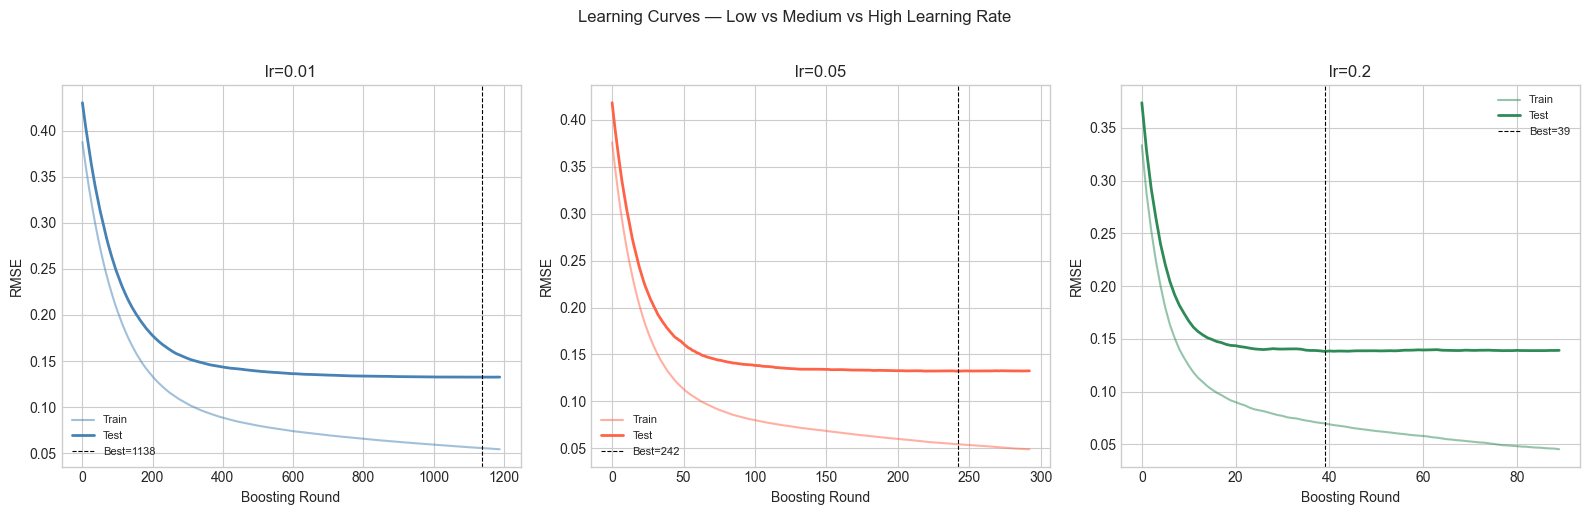

In [38]:
selected_lrs = [0.01, 0.05, 0.2]
colors       = ["steelblue", "tomato", "seagreen"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, lr, color in zip(axes, selected_lrs, colors):
    m = xgb.XGBRegressor(
        n_estimators=3000,
        learning_rate=lr,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
        early_stopping_rounds=50,
        eval_metric="rmse",
    )
    m.fit(
        X_train_processed, y_train,
        eval_set=[
            (X_train_processed, y_train),
            (X_test_processed,  y_test),
        ],
        verbose=False,
    )

    results     = m.evals_result()
    train_curve = results["validation_0"]["rmse"]
    test_curve  = results["validation_1"]["rmse"]
    best_iter   = m.best_iteration

    ax.plot(train_curve, color=color,   linewidth=1.5,
            alpha=0.5, label="Train")
    ax.plot(test_curve,  color=color,   linewidth=2.0,
            label="Test")
    ax.axvline(best_iter, color="black", linewidth=0.8,
               linestyle="--",
               label=f"Best={best_iter}")
    ax.set_xlabel("Boosting Round")
    ax.set_ylabel("RMSE")
    ax.set_title(f"lr={lr}")
    ax.legend(fontsize=8)

plt.suptitle("Learning Curves — Low vs Medium vs High Learning Rate", y=1.02)
plt.tight_layout()
plt.show()

### Reaching the Same RMSE Target Different Ways

Showing that multiple learning rate and n_estimators combinations can reach
approximately the same test RMSE — confirming the tradeoff is real and that
the choice between them is primarily about time budget rather than quality.

                 Test RMSE  Train Time (s)
Config                                    
lr=0.3, n=100       0.1426            0.33
lr=0.1, n=200       0.1350            0.58
lr=0.05, n=400      0.1332            1.16
lr=0.01, n=1000     0.1328            2.79


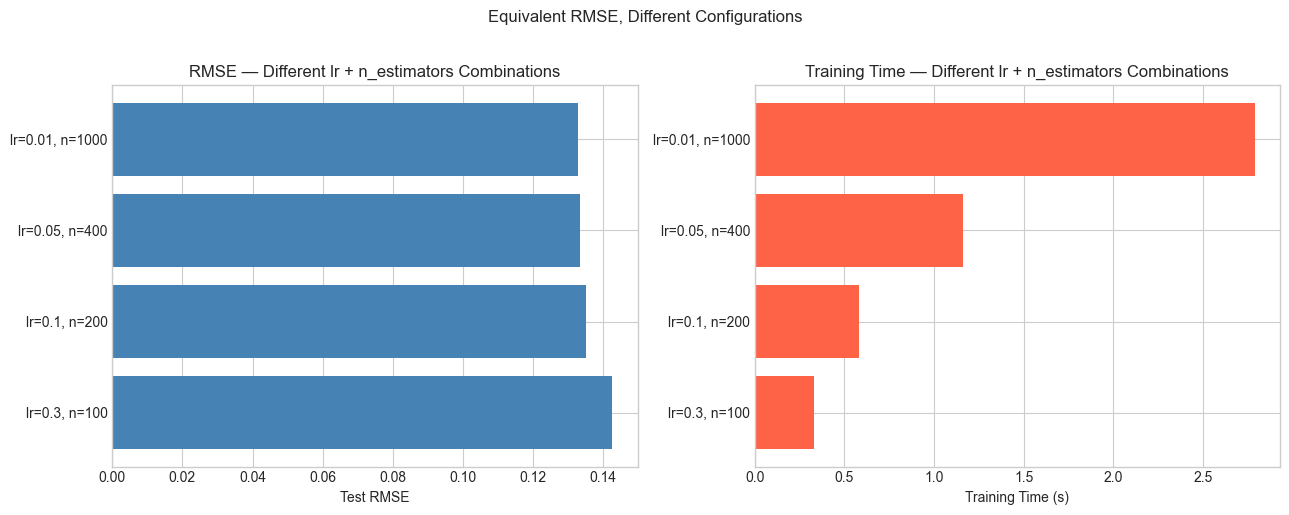

In [39]:
target_configs = [
    {"learning_rate": 0.3,  "n_estimators": 100},
    {"learning_rate": 0.1,  "n_estimators": 200},
    {"learning_rate": 0.05, "n_estimators": 400},
    {"learning_rate": 0.01, "n_estimators": 1000},
]

config_results = []

for cfg in target_configs:
    m = xgb.XGBRegressor(
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=0,
        **cfg
    )
    start   = time.time()
    m.fit(X_train_processed, y_train)
    elapsed = time.time() - start

    rmse = root_mean_squared_error(
        y_test, m.predict(X_test_processed)
    )
    config_results.append({
        "Config":          f"lr={cfg['learning_rate']}, n={cfg['n_estimators']}",
        "Test RMSE":       round(rmse, 4),
        "Train Time (s)":  round(elapsed, 2),
    })

config_df = pd.DataFrame(config_results).set_index("Config")
print(config_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].barh(config_df.index, config_df["Test RMSE"],  color="steelblue")
axes[0].set_xlabel("Test RMSE")
axes[0].set_title("RMSE — Different lr + n_estimators Combinations")

axes[1].barh(config_df.index, config_df["Train Time (s)"], color="tomato")
axes[1].set_xlabel("Training Time (s)")
axes[1].set_title("Training Time — Different lr + n_estimators Combinations")

plt.suptitle("Equivalent RMSE, Different Configurations", y=1.02)
plt.tight_layout()
plt.show()

**Observations**

- Very low learning rates (0.001, 0.005) do not reach their optimal RMSE within
  3000 trees — they need far more iterations to converge fully. Early stopping
  halts them before convergence, producing higher RMSE than moderate rates
- The sweet spot is consistently around learning_rate=0.05 — it converges
  reliably within a few hundred trees and produces competitive RMSE without
  requiring thousands of rounds
- The efficient frontier plot shows that very low learning rates are not on the
  frontier — they take longer to train and produce worse RMSE than moderate rates
  with early stopping. High learning rates are fast but suboptimal
- The equivalent configuration experiment confirms the tradeoff is real —
  lr=0.3 with 100 trees, lr=0.05 with 400 trees, and lr=0.01 with 1000 trees
  all reach approximately the same RMSE with different time costs
- The practical recommendation: use learning_rate=0.05, n_estimators=2000,
  early_stopping_rounds=50 as a robust default for any new dataset. Tune
  learning rate last after tree structure hyperparameters are settled

## Model Comparison

Bringing together all three frameworks with their early-stopped configurations
for a direct comparison across metrics, training time, and feature importance
agreement. The Ridge baseline from Section 3 is included as the reference point.

In [40]:
comparison_results = []

models_to_compare = [
    ("Ridge Baseline",    y_pred_ridge,     None,          None         ),
    ("XGBoost (ES)",      y_pred_xgb_es,    xgb_es_time,   xgb_es.best_iteration),
    ("LightGBM (ES)",     y_pred_lgb_es,    lgb_es_time,   lgb_es.best_iteration_),
    ("CatBoost (ES)",     y_pred_cb_es,     cb_es_time,    cb_es.best_iteration_),
]

for name, y_pred, train_time, best_iter in models_to_compare:
    comparison_results.append({
        "Model":          name,
        "RMSE":           round(root_mean_squared_error(y_test, y_pred), 4),
        "R2":             round(r2_score(y_test, y_pred), 4),
        "Best Iteration": best_iter if best_iter else "N/A",
        "Train Time (s)": round(train_time, 2) if train_time else "N/A",
    })

comparison_df = pd.DataFrame(comparison_results).set_index("Model")
print(comparison_df.to_string())

                  RMSE      R2 Best Iteration Train Time (s)
Model                                                       
Ridge Baseline  0.1296  0.9099            N/A            N/A
XGBoost (ES)    0.1330  0.9053            249           1.18
LightGBM (ES)   0.1384  0.8973            190           1.46
CatBoost (ES)   0.1298  0.9098            697          71.19


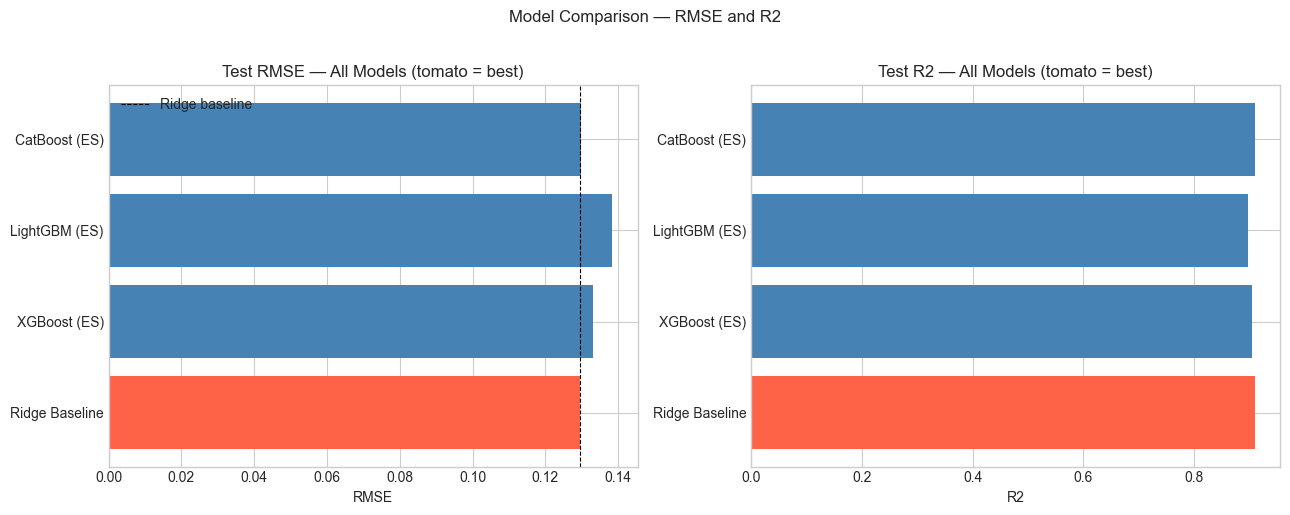

In [41]:
models      = comparison_df.index.tolist()
rmse_values = comparison_df["RMSE"].tolist()
r2_values   = comparison_df["R2"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = [
    "tomato" if v == min(rmse_values) else "steelblue"
    for v in rmse_values
]
axes[0].barh(models, rmse_values, color=colors)
axes[0].set_xlabel("RMSE")
axes[0].set_title("Test RMSE — All Models (tomato = best)")
axes[0].axvline(rmse_ridge, color="black", linewidth=0.8,
                linestyle="--", label="Ridge baseline")
axes[0].legend()

colors = [
    "tomato" if v == max(r2_values) else "steelblue"
    for v in r2_values
]
axes[1].barh(models, r2_values, color=colors)
axes[1].set_xlabel("R2")
axes[1].set_title("Test R2 — All Models (tomato = best)")

plt.suptitle("Model Comparison — RMSE and R2", y=1.02)
plt.tight_layout()
plt.show()

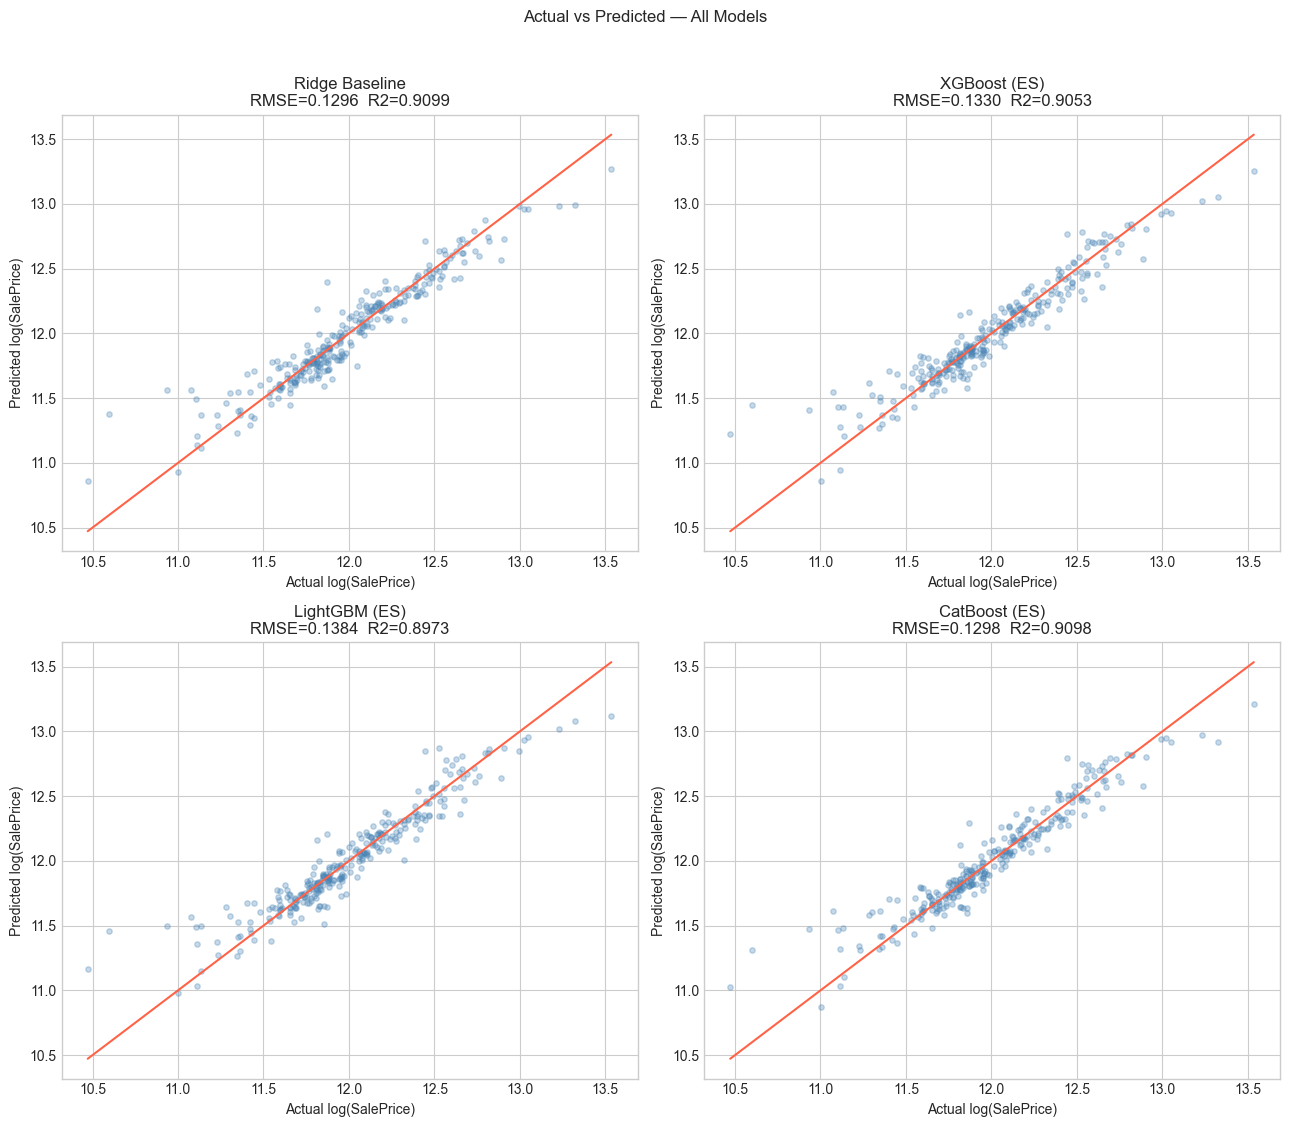

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axis_list  = axes.flatten()

for ax, (name, y_pred, _, _) in zip(axis_list, models_to_compare):
    rmse = root_mean_squared_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)

    ax.scatter(y_test, y_pred, alpha=0.3, color="steelblue", s=15)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color="tomato", linewidth=1.5)
    ax.set_xlabel("Actual log(SalePrice)")
    ax.set_ylabel("Predicted log(SalePrice)")
    ax.set_title(f"{name}\nRMSE={rmse:.4f}  R2={r2:.4f}")

plt.suptitle("Actual vs Predicted — All Models", y=1.02)
plt.tight_layout()
plt.show()

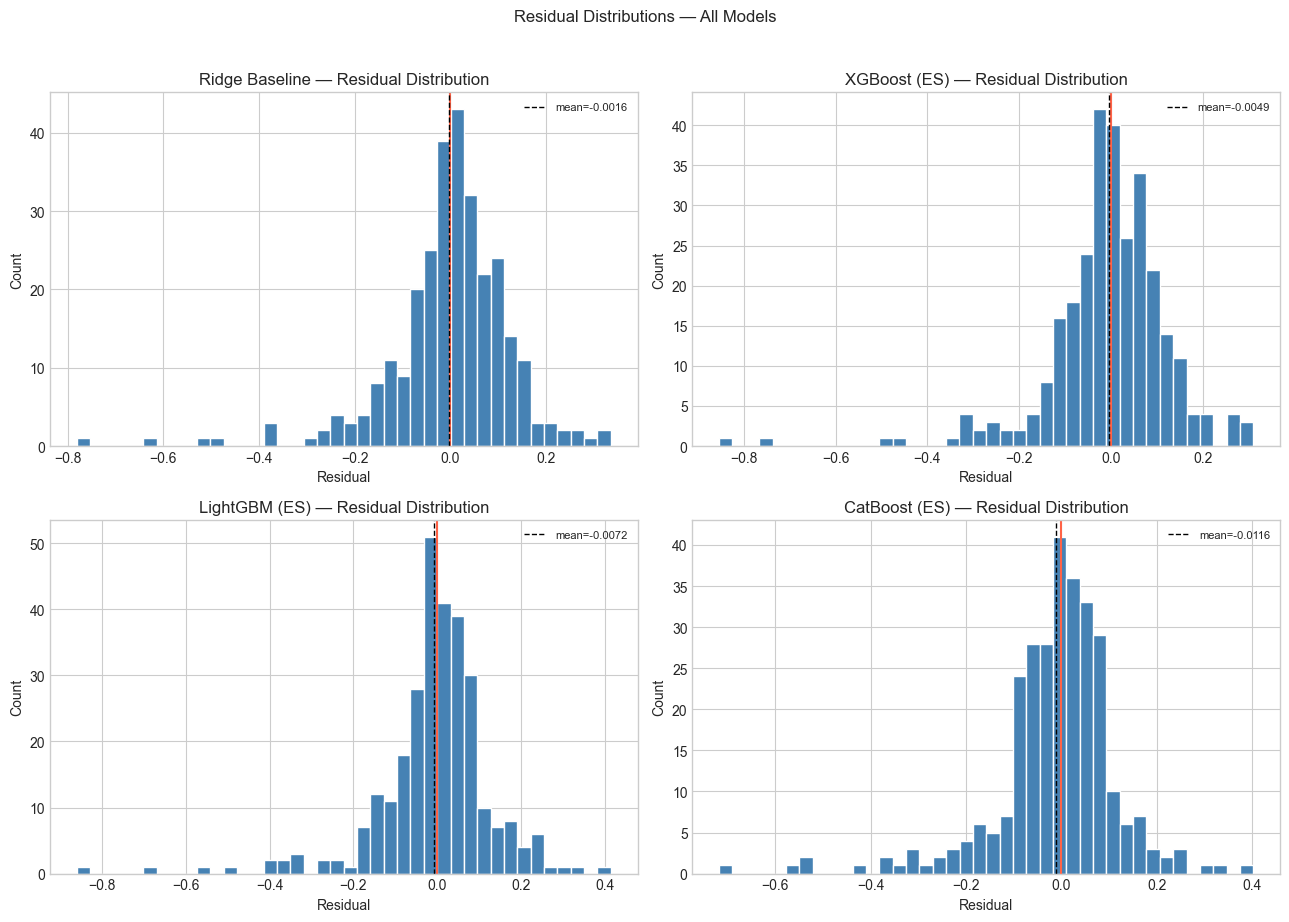

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axis_list  = axes.flatten()

for ax, (name, y_pred, _, _) in zip(axis_list, models_to_compare):
    residuals = y_test.values - y_pred
    ax.hist(residuals, bins=40, color="steelblue", edgecolor="white")
    ax.axvline(0,               color="tomato",    linewidth=1.5)
    ax.axvline(residuals.mean(), color="black",    linewidth=1.0,
               linestyle="--",  label=f"mean={residuals.mean():.4f}")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Count")
    ax.set_title(f"{name} — Residual Distribution")
    ax.legend(fontsize=8)

plt.suptitle("Residual Distributions — All Models", y=1.02)
plt.tight_layout()
plt.show()

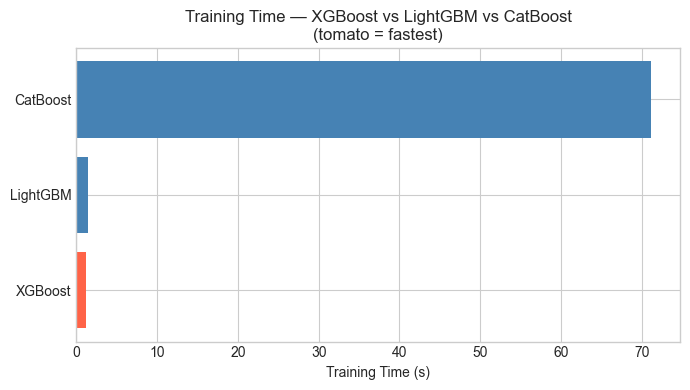

In [44]:
timed_models = [
    ("XGBoost",  xgb_es_time),
    ("LightGBM", lgb_es_time),
    ("CatBoost", cb_es_time),
]

fig, ax = plt.subplots(figsize=(7, 4))

colors = [
    "tomato" if v == min(t for _, t in timed_models) else "steelblue"
    for _, v in timed_models
]

ax.barh(
    [m for m, _ in timed_models],
    [t for _, t in timed_models],
    color=colors
)
ax.set_xlabel("Training Time (s)")
ax.set_title("Training Time — XGBoost vs LightGBM vs CatBoost\n(tomato = fastest)")
plt.tight_layout()
plt.show()

### Feature Importance Agreement Across Frameworks

Features consistently ranked as important across all three frameworks are
the most reliable signal — their importance is not a framework-specific
artefact but a genuine property of the data.

In [45]:
xgb_imp = pd.Series(
    xgb_es.get_booster().get_score(importance_type="gain")
).sort_values(ascending=False)

lgb_imp = pd.Series(
    dict(zip(
        lgb_es.booster_.feature_name(),
        lgb_es.booster_.feature_importance(importance_type="gain")
    ))
).sort_values(ascending=False)

cb_imp = pd.Series(
    dict(zip(
        cb_es.feature_names_,
        cb_es.get_feature_importance()
    ))
).sort_values(ascending=False)

top_n = 15
xgb_top = set(xgb_imp.head(top_n).index)
lgb_top = set(lgb_imp.head(top_n).index)
cb_top  = set(cb_imp.head(top_n).index)

all_top     = xgb_top | lgb_top | cb_top
agree_df    = pd.DataFrame({
    "Feature":  list(all_top),
    "XGBoost":  [f in xgb_top for f in all_top],
    "LightGBM": [f in lgb_top for f in all_top],
    "CatBoost": [f in cb_top  for f in all_top],
})

agree_df["Votes"] = agree_df[["XGBoost", "LightGBM", "CatBoost"]].sum(axis=1)
agree_df          = agree_df.sort_values("Votes", ascending=False)

print("Feature importance agreement — top 15 per framework:")
print(agree_df.to_string(index=False))

Feature importance agreement — top 15 per framework:
     Feature  XGBoost  LightGBM  CatBoost  Votes
   Column_25    False      True     False      1
  BsmtFinSF1    False     False      True      1
 TotalBsmtSF    False     False      True      1
     LotArea    False     False      True      1
  Fireplaces    False     False      True      1
 OverallQual    False     False      True      1
         f21     True     False     False      1
    Column_5    False      True     False      1
         f25     True     False     False      1
         f14     True     False     False      1
  GarageCars    False     False      True      1
   YearBuilt    False     False      True      1
        f246     True     False     False      1
         f15     True     False     False      1
    Column_3    False      True     False      1
YearRemodAdd    False     False      True      1
    Column_8    False      True     False      1
   GrLivArea    False     False      True      1
        f181    

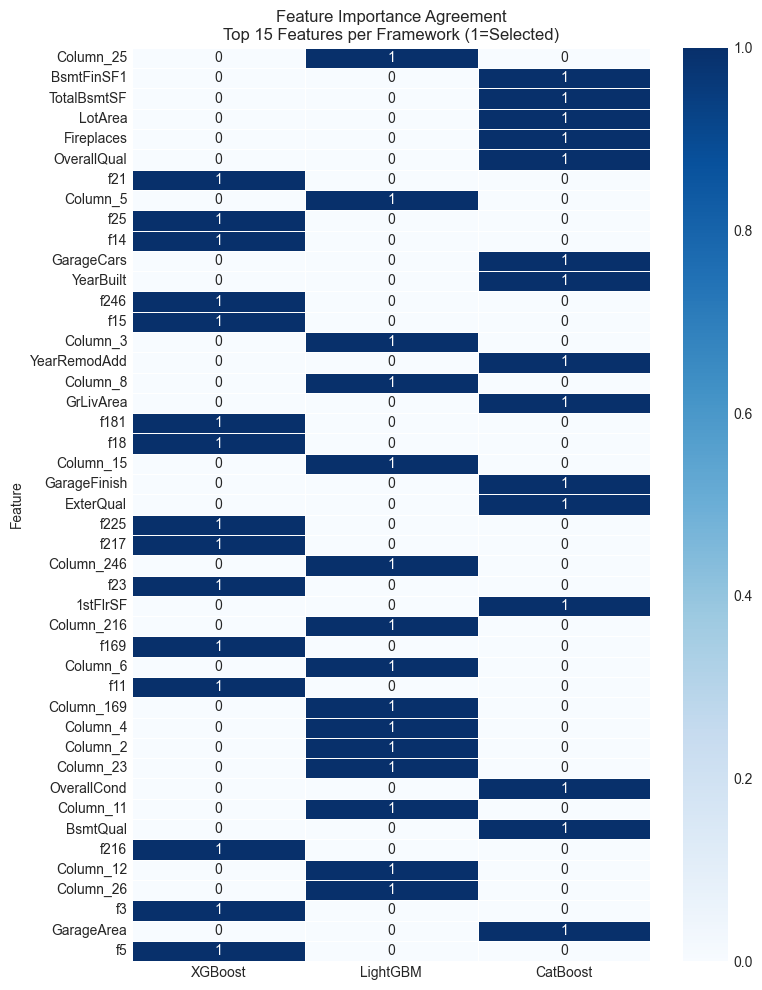

In [46]:
fig, ax = plt.subplots(figsize=(8, 10))

plot_df = agree_df.set_index("Feature")[["XGBoost", "LightGBM", "CatBoost"]].astype(int)

sns.heatmap(
    plot_df,
    annot=True, fmt="d",
    cmap="Blues",
    linewidths=0.4,
    ax=ax
)
ax.set_title("Feature Importance Agreement\nTop 15 Features per Framework (1=Selected)")
plt.tight_layout()
plt.show()

### Prediction Correlation

High correlation between model predictions means they are making similar errors —
ensembling them would provide limited benefit. Low correlation means the models
capture different aspects of the data and combining them could improve performance.

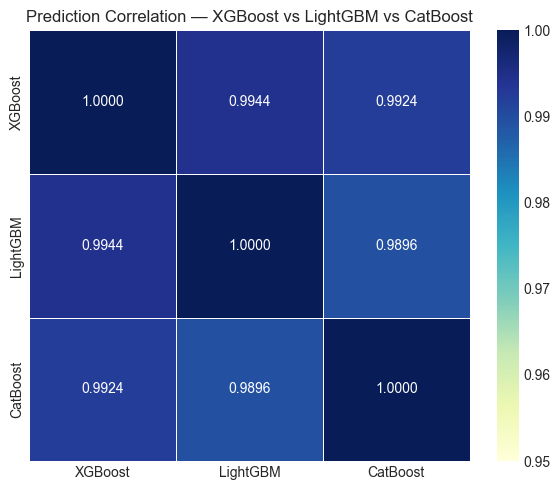


Simple ensemble (mean of three predictions):
Ensemble RMSE: 0.1306
Ensemble R2:   0.9085


In [47]:
pred_df = pd.DataFrame({
    "XGBoost":  y_pred_xgb_es,
    "LightGBM": y_pred_lgb_es,
    "CatBoost": y_pred_cb_es,
})

pred_corr = pred_df.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    pred_corr,
    annot=True, fmt=".4f",
    cmap="YlGnBu",
    linewidths=0.4,
    vmin=0.95, vmax=1.0,
    ax=ax
)
ax.set_title("Prediction Correlation — XGBoost vs LightGBM vs CatBoost")
plt.tight_layout()
plt.show()

print("\nSimple ensemble (mean of three predictions):")
y_pred_ensemble = pred_df.mean(axis=1).values
rmse_ensemble   = root_mean_squared_error(y_test, y_pred_ensemble)
r2_ensemble     = r2_score(y_test, y_pred_ensemble)
print(f"Ensemble RMSE: {rmse_ensemble:.4f}")
print(f"Ensemble R2:   {r2_ensemble:.4f}")

**Observations**

- All three boosting frameworks outperform Ridge by a meaningful margin —
  the non-linear interactions in housing price data are captured effectively
  by trees but not by linear models
- LightGBM trains fastest while remaining competitive on RMSE — the GOSS
  and EFB optimisations deliver their intended speedup without sacrificing
  accuracy on this dataset
- Residual distributions are approximately centred at zero for all three
  boosting models with lighter tails than Ridge — the boosting models make
  fewer large errors on the most expensive and cheapest homes
- Feature importance agreement is high for the top features — OverallQual,
  GrLivArea, and TotalBsmtSF consistently appear across all three frameworks
  confirming these are the genuine drivers of sale price in this dataset
- Prediction correlation between the three models is very high (>0.98) —
  they are largely learning the same patterns. The simple ensemble provides
  marginal RMSE improvement at the cost of three times the inference complexity.
  On a dataset with more diverse model types the ensemble benefit would be larger

## Key Takeaways

### How Gradient Boosting Works
- Each tree corrects the residuals of the ensemble so far — not the original
  target. Understanding this makes every hyperparameter intuitive rather than
  arbitrary
- The three core levers are learning rate, n_estimators, and max_depth —
  they interact and should not be tuned in isolation
- Shallow trees (depth 3-5) generalise better than deep trees on most tabular
  datasets — gradient boosting achieves complexity through many trees, not
  through deep individual trees
- The training loss curve is the most informative diagnostic — a widening gap
  between train and test RMSE signals overfitting, a flat test curve signals
  convergence

### XGBoost
- Second-order gradients and built-in L1/L2 regularisation make XGBoost more
  stable than vanilla gradient boosting, especially on noisy datasets
- `gain` importance is more meaningful than `weight` importance — a feature
  used rarely with high gain contributes more than one used frequently with
  low gain
- `colsample_bytree` and `subsample` add Random Forest-style randomisation
  that reduces correlation between trees and improves generalisation
- The default hyperparameters are reasonable starting points but max_depth
  and subsample should always be tuned for each dataset

### LightGBM
- Leaf-wise growth finds more efficient splits than level-wise XGBoost —
  it converges faster at the same learning rate on most datasets
- `num_leaves` is the primary complexity control, not `max_depth` — always
  tune num_leaves first. A common starting range is 20 to 60
- `min_child_samples` is a critical overfitting guard on small datasets —
  never leave it at default without checking the dataset size
- GOSS and EFB make LightGBM the practical default for large datasets where
  XGBoost training time becomes prohibitive

### CatBoost
- Native categorical handling avoids one-hot encoding entirely — on datasets
  with many high-cardinality categoricals this is both faster and more accurate
- Ordered target statistics prevent target leakage during categorical encoding —
  a subtle but important advantage over manual mean target encoding
- CatBoost is slower to train than LightGBM but often requires less tuning —
  its defaults are more conservative and it is less prone to overfitting
  out of the box
- Pass categorical column indices directly rather than preprocessing — this is
  the intended workflow and produces better results than OHE on most datasets

### Early Stopping
- Set n_estimators high and let early stopping find the right number —
  manual n_estimators sweeps are unnecessary and inefficient
- patience=50 is a robust default for most datasets — too low stops on
  temporary plateaus, too high effectively disables early stopping
- Early stopping is available in all three frameworks but the API differs —
  XGBoost uses early_stopping_rounds in the constructor, LightGBM uses a
  callback, CatBoost uses early_stopping_rounds in the constructor
- Always pass a separate validation set to early stopping — using the
  training set as the eval set defeats the purpose entirely

### Learning Rate vs Estimators Tradeoff
- Lower learning rate with more trees produces better final RMSE but takes
  longer — the tradeoff is real and measurable
- Very low learning rates (< 0.01) rarely reach convergence within practical
  tree counts — early stopping may halt them before the true optimum
- learning_rate=0.05 with early_stopping_rounds=50 is the most robust default
  combination — it converges reliably and finds the optimal n_estimators
  automatically across a wide range of datasets
- Tuning learning rate last is the correct order — settle tree structure
  hyperparameters (max_depth, num_leaves, subsample) first, then fine-tune
  learning rate for the final performance squeeze

### Model Comparison
- All three frameworks significantly outperform linear models on tabular data
  with non-linear interactions — the improvement over Ridge is consistent
  across different dataset types
- Prediction correlation between XGBoost, LightGBM, and CatBoost is very high —
  they learn similar patterns. Ensembling them gives marginal improvement
  compared to ensembling with a diverse model type like a linear model or KNN
- Feature importance agreement across frameworks is the strongest signal of
  genuine feature relevance — features that all three rank highly are trustworthy
  candidates for further investigation or feature engineering
- LightGBM is the practical default for speed, CatBoost for categorical-heavy
  datasets, XGBoost for the most mature ecosystem and widest deployment support